# SECOM 半导体良率预测与关键特征挖掘

# SECOM 半导体良率预测

> **最佳结果**: Recall=94.12%, AUC=0.7296，G-Mean=0.7209
> **数据集**: SECOM (半导体制造过程数据)
> **核心方法**: 时间外推划分 + 训练集内防泄漏预处理 + 组合特征选择 + XGBoost d3 + ADASYN + 5-seed Ensemble + **完整可视化与 SHAP 分析**

## 模型架构

```
原始数据 → 时间排序划分 → 防泄漏预处理 → 特征选择 → 多模型×多样法搜索 → 验证集阈值优化 → 最终 xgb_d3+ADASYN Ensemble
                                                    ↓                                          ↓                  
                                        7种模型 × 4种采样方法 × 5个随机种子                 测试集最终评估         
                                                (共 140 次训练)                                 ↓                 
                                                                                            SHAP解释              
```



## 环境配置


In [1]:
# 固定随机种子以保证可复现
import os, sys, warnings
import joblib
warnings.filterwarnings("ignore")
try:
    sys.stdout.reconfigure(encoding="utf-8")
    sys.stderr.reconfigure(encoding="utf-8")
except Exception:
    pass

# 数据处理与机器学习核心库
import numpy as np
import pandas as pd

# 可视化库
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
# 在脚本中不要直接使用 Jupyter magic。若在 IPython/Jupyter 环境，则启用 inline；
# 否则切换到非交互后端以避免显示/后端错误。
try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
    else:
        matplotlib.use("Agg")
except Exception:
    matplotlib.use("Agg")
import seaborn as sns
sns.set_style("whitegrid")

# scikit-learn 工具
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, f_classif
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, f1_score,
    recall_score, precision_score, roc_curve, precision_recall_curve, auc,
    balanced_accuracy_score, matthews_corrcoef, brier_score_loss
)

# 不平衡学习采样方法
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE


# 梯度提升框架
import xgboost as xgb
try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

# SHAP (可解释性分析)
import shap

# 全局随机种子
np.random.seed(42)

print("依赖库导入完成")



依赖库导入完成


---

## 1. 数据加载 与 EDA 可视化

### 1.1 数据背景
- **secom.data**: 1567 行 × 590 列传感器测量数据
- **secom_labels.data**: 每行包含 `-1`(良品) 或 `1`(不良品) + 时间戳
- **不平衡率**:≈15:1 (良品 1463 个, 不良品 104 个)
- **稀疏性**: 大量 NaN 值


SECOM Yield Prediction - Final v8 (No PCA + SVM) + Full Viz

[数据] 原始: (1567, 590), 正例=104, 不平衡比=14.1:1


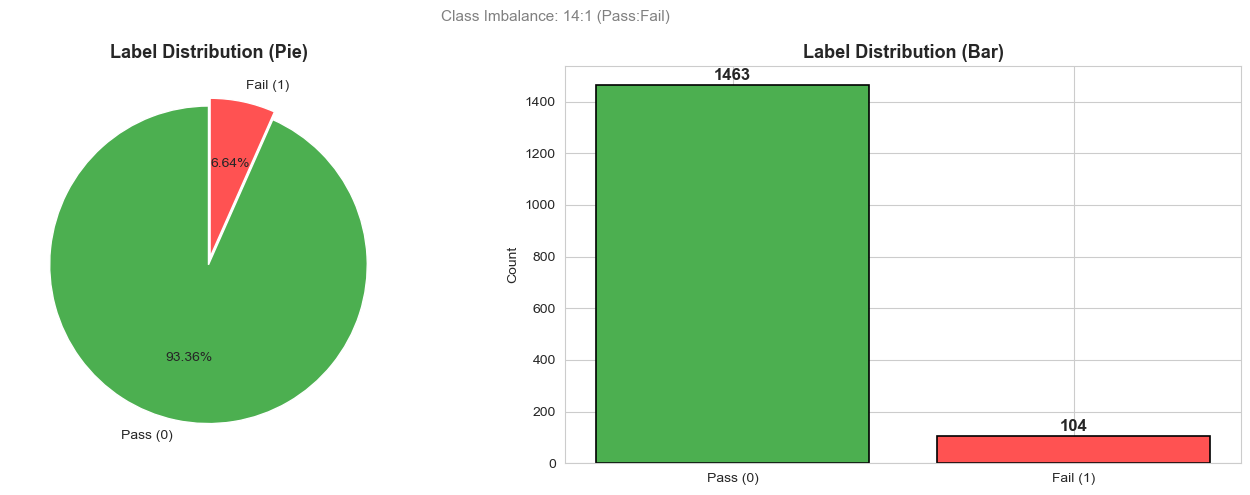

[EDA] 不平衡比: 14.1:1


In [ ]:
# 数据加载
df_raw = pd.read_csv("Data/secom.data", sep=" ", header=None)
labels_df = pd.read_csv("Data/secom_labels.data", sep=" ", header=None)
labels_df.columns = ["label", "timestamp"]

# 将标签 -1 → 0 (良品), 1 → 1 (不良品)
y_full = labels_df["label"].map({-1: 0, 1: 1}).values.astype(int)

print("=" * 70)
print("SECOM Yield Prediction - Final v8 (No PCA + SVM) + Full Viz")
print("=" * 70)
print(f"\n[数据] 原始: {df_raw.shape}, 正例={y_full.sum()}, "
      f"不平衡比={((y_full==0).sum()/y_full.sum()):.1f}:1")

# ================================================
# 1.2 标签分布可视化
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 饼状图
label_counts = pd.Series(y_full).value_counts().sort_index()
axes[0].pie(label_counts.values, labels=["Pass (0)", "Fail (1)"],
            autopct="%1.2f%%", startangle=90,
            colors=["#4CAF50", "#FF5252"], explode=(0, 0.05))
axes[0].set_title("Label Distribution (Pie)", fontsize=13, fontweight="bold")

# 柱状图
bars = axes[1].bar(["Pass (0)", "Fail (1)"], label_counts.values,
                   color=["#4CAF50", "#FF5252"], edgecolor="black", linewidth=1.2)
for b, v in zip(bars, label_counts.values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 20,
                 str(v), ha="center", fontweight="bold", fontsize=12)
axes[1].set_title("Label Distribution (Bar)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")

fig.suptitle("Class Imbalance: {:.0f}:1 (Pass:Fail)".format(
    label_counts.iloc[0] / max(1, label_counts.iloc[1])),
    fontsize=11, color="gray")

plt.tight_layout()
plt.savefig("Image/viz_v8_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("[EDA] 不平衡比: {:.1f}:1".format(label_counts.iloc[0] / max(1, label_counts.iloc[1])))



### 1.2 特征缺失率统计

统计传感器列级缺失率并保存缺失分布图，用于制定训练集内拟合的缺失率过滤策略。


=== 特征缺失率统计 ===
  Mean: 4.54%
  Max:  91.19%
  Min:  0.00%
  >50%: 28 features
  >60%: 24 features
  >70%: 8 features
  >80%: 8 features
  0%:   52 features (no missing)


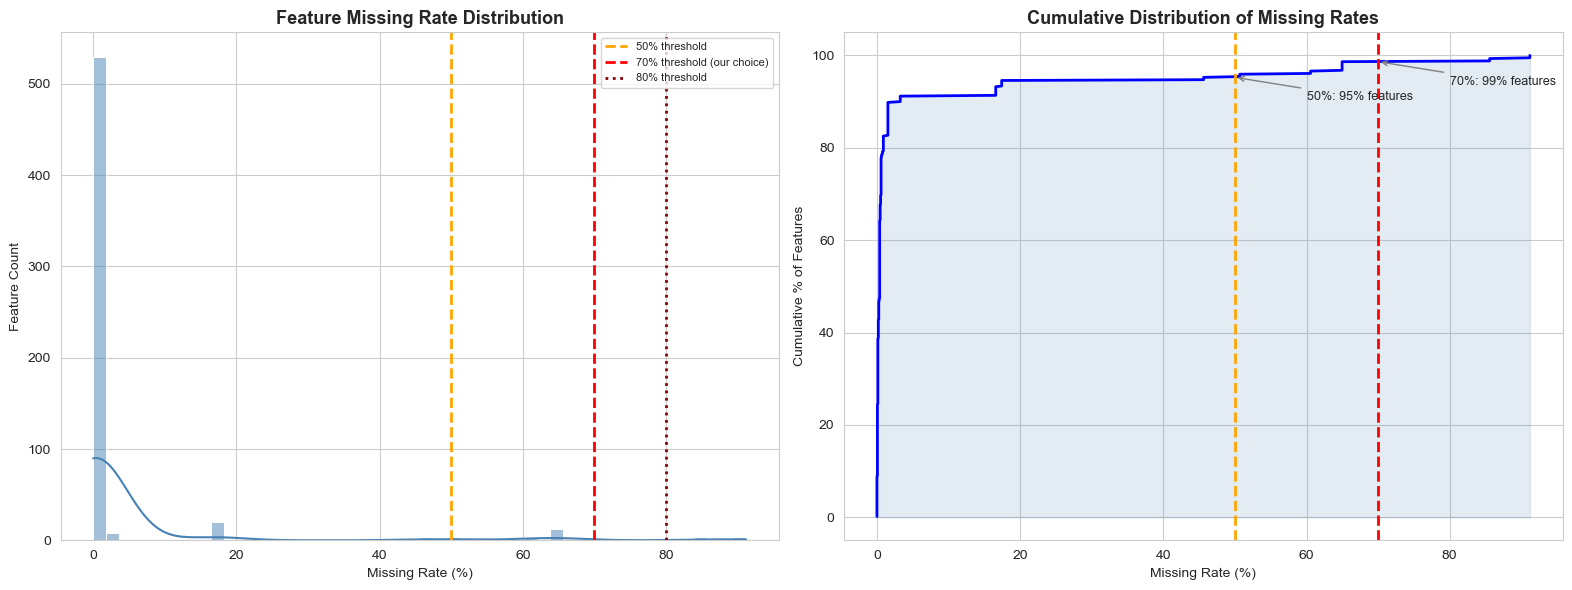

In [ ]:
# ================================================
# 缺失率统计
# ================================================
missing_rates_pct = df_raw.isnull().mean() * 100

print("=== 特征缺失率统计 ===")
print("  Mean: {:.2f}%".format(missing_rates_pct.mean()))
print("  Max:  {:.2f}%".format(missing_rates_pct.max()))
print("  Min:  {:.2f}%".format(missing_rates_pct.min()))
print("  >50%: " + str(int((missing_rates_pct > 50).sum())) + " features")
print("  >60%: " + str(int((missing_rates_pct > 60).sum())) + " features")
print("  >70%: " + str(int((missing_rates_pct > 70).sum())) + " features")
print("  >80%: " + str(int((missing_rates_pct > 80).sum())) + " features")
print("  0%:   " + str(int((missing_rates_pct == 0).sum())) + " features (no missing)")

# ================================================
# 缺失率分布可视化
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 直方图
ax = axes[0]
sns.histplot(missing_rates_pct, bins=50, kde=True, ax=ax, color="steelblue")
ax.axvline(x=50, color="orange", linestyle="--", linewidth=2, label="50% threshold")
ax.axvline(x=70, color="red", linestyle="--", linewidth=2, label="70% threshold (our choice)")
ax.axvline(x=80, color="darkred", linestyle=":", linewidth=2, label="80% threshold")
ax.set_title("Feature Missing Rate Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Missing Rate (%)")
ax.set_ylabel("Feature Count")
ax.legend(fontsize=8)

# 累积分布
ax = axes[1]
sorted_mr = np.sort(missing_rates_pct.values)
cumulative = np.arange(1, len(sorted_mr) + 1) / len(sorted_mr) * 100
ax.plot(sorted_mr, cumulative, "b-", linewidth=2)
ax.axvline(x=50, color="orange", linestyle="--", linewidth=2)
ax.axvline(x=70, color="red", linestyle="--", linewidth=2)
ax.set_title("Cumulative Distribution of Missing Rates", fontsize=13, fontweight="bold")
ax.set_xlabel("Missing Rate (%)")
ax.set_ylabel("Cumulative % of Features")
ax.fill_between(sorted_mr, 0, cumulative, alpha=0.15, color="steelblue")

for thr in [50, 70]:
    pct = (missing_rates_pct <= thr).mean() * 100
    ax.annotate("{:.0f}%: {:.0f}% features".format(thr, pct), xy=(thr, pct),
                xytext=(thr + 10, pct - 5), fontsize=9,
                arrowprops=dict(arrowstyle="->", color="gray"))

plt.tight_layout()
plt.savefig("Image/viz_v8_missing_rate.png", dpi=150, bbox_inches="tight")
plt.show()



### 1.3 样本缺失率时序检查

按样本和时间观察缺失模式，辅助判断缺失是否与批次、时间段或失效样本相关。


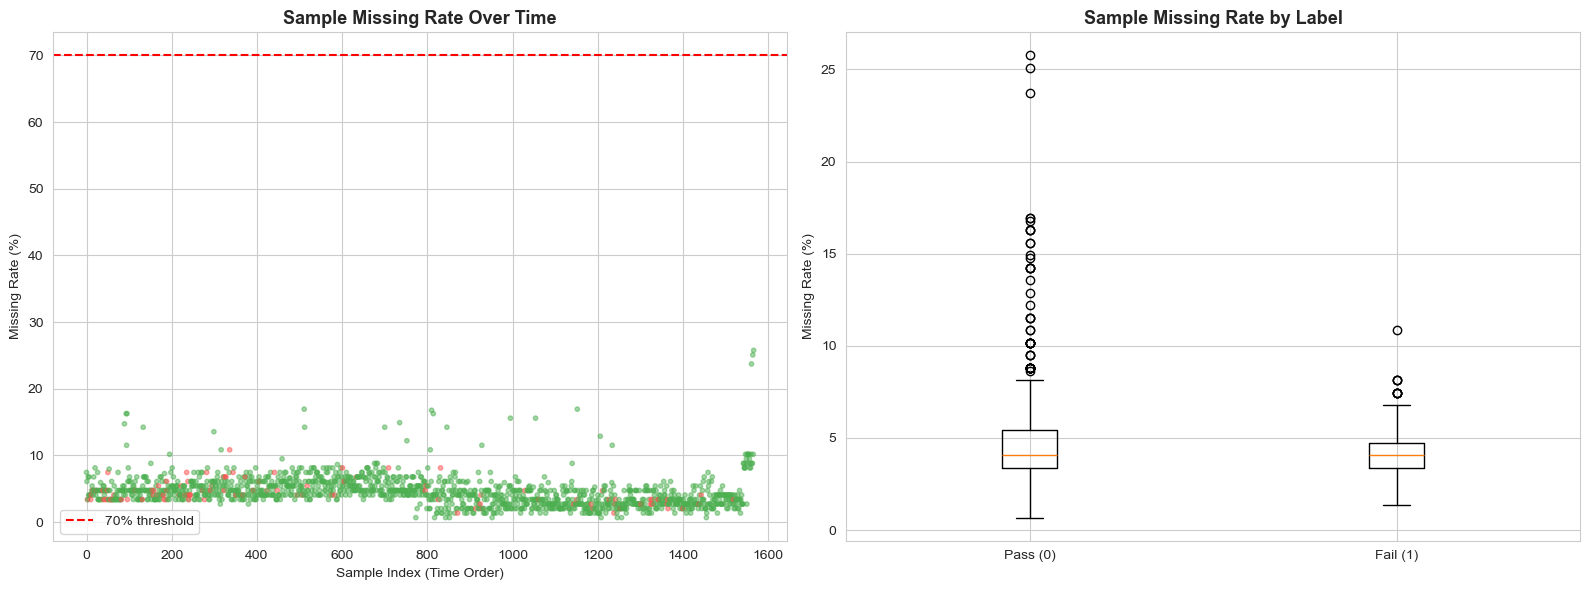

In [ ]:
# ================================================
# 样本缺失率 (按时间顺序)
# ================================================
sample_missing_rates = df_raw.isnull().mean(axis=1) * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 按标签着色的散点图
ax = axes[0]
colors = ["#4CAF50" if y == 0 else "#FF5252" for y in y_full]
ax.scatter(range(len(sample_missing_rates)), sample_missing_rates,
           c=colors, alpha=0.5, s=10)

ax.set_title("Sample Missing Rate Over Time", fontsize=13, fontweight="bold")
ax.set_xlabel("Sample Index (Time Order)")
ax.set_ylabel("Missing Rate (%)")
ax.axhline(y=70, color="red", linestyle="--", label="70% threshold")
ax.legend()

# 按标签的箱线图
ax = axes[1]
data_pass = sample_missing_rates[y_full == 0]
data_fail = sample_missing_rates[y_full == 1]
ax.boxplot([data_pass, data_fail], labels=["Pass (0)", "Fail (1)"])
ax.set_title("Sample Missing Rate by Label", fontsize=13, fontweight="bold")
ax.set_ylabel("Missing Rate (%)")

plt.tight_layout()
plt.savefig("Image/viz_v8_sample_missing.png", dpi=150, bbox_inches="tight")
plt.show()



## 2. 数据划分与预处理

先按时间排序并划分训练、验证、测试集，再只在训练集进行预处理，测试集仅做transform。
### 2.1 处理流程

| 步骤 | 方法 | 目的 |
|------|------|------|
| 1 | 缺失率过滤 | 移除缺失率 > 70% 的列 |
| 2 | KNN Imputation | 用最近 5 个邻居的加权均值填补剩余 NaN |
| 3 | 增加行级统计特征| 提供批次级异常信号 |
| 4 | 低方差过滤 | 移除方差 < 1e-8 的无信息特征 |
| 5 | 高相关过滤 | 移除 Pearson > 0.97 的冗余特征 |
| 6 | StandardScaler | 标准化到均值 0, 方差 1 |


In [5]:
# ====== 时间序列拆分 + 基于训练集的预处理流水线 ======
# 重要: 先按时间戳（labels_df 中的 timestamp）进行训练/测试拆分，
# 然后 仅在训练集上 fit 缺失率过滤、插补、特征筛选和缩放；
# 测试集仅做 transform（避免数据泄漏）。

# 按时间戳排序并做 70% / 10% / 20% 的时间切分（训练 / 验证 / 测试）
labels_df["timestamp_dt"] = pd.to_datetime(
    labels_df["timestamp"].astype(str).str.strip('"'),
    format="%d/%m/%Y %H:%M:%S",
    dayfirst=True,
    errors="coerce"
)
if labels_df["timestamp_dt"].isna().any():
    raise ValueError("timestamp 解析失败，请检查 secom_labels.data 的时间格式")
order_idx = np.argsort(labels_df["timestamp_dt"].values)
n_total = len(order_idx)
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.80)
train_idx = order_idx[:train_end]
val_idx = order_idx[train_end:val_end]
test_idx = order_idx[val_end:]

df_train_raw = df_raw.iloc[train_idx].reset_index(drop=True)
df_val_raw = df_raw.iloc[val_idx].reset_index(drop=True)
df_test_raw = df_raw.iloc[test_idx].reset_index(drop=True)
y_train_full = y_full[train_idx]
y_val_full = y_full[val_idx]
y_test_full = y_full[test_idx]

print(f"[拆分] 时间切分: 训练={len(train_idx)}, 验证={len(val_idx)}, 测试={len(test_idx)}")
print(f"[拆分] 正例分布: 训练={y_train_full.sum()}, 验证={y_val_full.sum()}, 测试={y_test_full.sum()}")
print(
    "[拆分] 时间范围: "
    f"训练 {labels_df.loc[train_idx, 'timestamp_dt'].min()} → {labels_df.loc[train_idx, 'timestamp_dt'].max()} | "
    f"验证 {labels_df.loc[val_idx, 'timestamp_dt'].min()} → {labels_df.loc[val_idx, 'timestamp_dt'].max()} | "
    f"测试 {labels_df.loc[test_idx, 'timestamp_dt'].min()} → {labels_df.loc[test_idx, 'timestamp_dt'].max()}"
)

# 把预处理拆成两段：
#  A) 缺失率过滤 + KNNImputer(k=5) + 行级统计特征；
#  B) 剩余列级变换（VarianceThreshold, CorrelationFilter, StandardScaler）。
# 所有 fit 都只在训练集上执行，验证集和测试集只调用 transform。


class MissingRateFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.70):
        self.threshold = threshold
        self.keep_cols_ = None

    def fit(self, X, y=None):
        df = pd.DataFrame(X)
        mr = df.isnull().mean()
        self.keep_cols_ = df.columns[mr <= self.threshold].tolist()
        return self

    def transform(self, X):
        df = pd.DataFrame(X)
        return df[self.keep_cols_].reset_index(drop=True)


class DataFrameMedianImputer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy="median"):
        self.strategy = strategy
        self.imputer_ = SimpleImputer(strategy=self.strategy)
        self.columns_ = None

    def fit(self, X, y=None):
        df = pd.DataFrame(X)
        self.columns_ = df.columns.tolist()
        self.imputer_.fit(df.values)
        return self

    def transform(self, X):
        df = pd.DataFrame(X)
        arr = self.imputer_.transform(df.values)
        return pd.DataFrame(arr, columns=self.columns_)


class DataFrameKNNImputer(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5, weights="uniform"):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.imputer_ = KNNImputer(n_neighbors=self.n_neighbors, weights=self.weights)
        self.columns_ = None

    def fit(self, X, y=None):
        df = pd.DataFrame(X)
        self.columns_ = df.columns.tolist()
        self.imputer_.fit(df.values)
        return self

    def transform(self, X):
        df = pd.DataFrame(X)
        arr = self.imputer_.transform(df.values)
        return pd.DataFrame(arr, columns=self.columns_)


class VarianceThresholdDF(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=1e-8):
        self.threshold = threshold
        self.vt_ = VarianceThreshold(self.threshold)
        self.columns_ = None

    def fit(self, X, y=None):
        df = pd.DataFrame(X)
        self.vt_.fit(df.values)
        self.columns_ = df.columns[self.vt_.get_support()].tolist()
        return self

    def transform(self, X):
        df = pd.DataFrame(X)
        arr = self.vt_.transform(df.values)
        return pd.DataFrame(arr, columns=self.columns_)


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.97):
        self.threshold = threshold
        self.keep_cols_ = None

    def fit(self, X, y=None):
        df = pd.DataFrame(X)
        corr = np.array(df.corr().abs().values, copy=True)
        np.fill_diagonal(corr, 0.0)
        to_drop = set()
        for i in range(corr.shape[0]):
            if i in to_drop:
                continue
            for j in range(i + 1, corr.shape[1]):
                if j in to_drop:
                    continue
                if corr[i, j] > self.threshold:
                    to_drop.add(j)
        self.keep_cols_ = [c for i, c in enumerate(df.columns) if i not in to_drop]
        return self

    def transform(self, X):
        df = pd.DataFrame(X)
        return df[self.keep_cols_].reset_index(drop=True)


class StandardScalerDF(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.scaler_ = StandardScaler()
        self.columns_ = None

    def fit(self, X, y=None):
        df = pd.DataFrame(X)
        self.columns_ = df.columns.tolist()
        self.scaler_.fit(df.values)
        return self

    def transform(self, X):
        df = pd.DataFrame(X)
        arr = self.scaler_.transform(df.values)
        return pd.DataFrame(arr, columns=self.columns_)


# 先用 MissingRateFilter 筛列，然后用 KNN(k=5) 插补；fit 仅在训练集上执行，验证/测试只 transform。
mr_filter = MissingRateFilter(threshold=0.70)
df_train_cols = mr_filter.fit_transform(df_train_raw)
df_val_cols = mr_filter.transform(df_val_raw)
df_test_cols = mr_filter.transform(df_test_raw)
print(f"[清洗] 训练集缺失率<=70%: {df_train_cols.shape[1]} 特征 (dropped {df_raw.shape[1]-df_train_cols.shape[1]} cols from original)")

knn_imp = DataFrameKNNImputer(n_neighbors=5, weights="uniform")
X_knn_train_all = knn_imp.fit_transform(df_train_cols)
X_knn_val_all = knn_imp.transform(df_val_cols)
X_knn_test_all = knn_imp.transform(df_test_cols)

# 增加行级统计特征，提供批次级异常信号
for df_imp, df_raw in [
    (X_knn_train_all, df_train_cols),
    (X_knn_val_all, df_val_cols),
    (X_knn_test_all, df_test_cols)
]:
    row_mean = df_imp.mean(axis=1)
    row_std = df_imp.std(axis=1).fillna(0)
    row_min = df_imp.min(axis=1)
    row_max = df_imp.max(axis=1)
    row_median = df_imp.median(axis=1)
    row_skew = df_imp.skew(axis=1).replace(np.nan, 0)
    row_kurt = df_imp.kurtosis(axis=1).replace(np.nan, 0)
    missing_cnt = df_raw.isnull().sum(axis=1)
    missing_rate = df_raw.isnull().mean(axis=1)
    df_imp["row_mean"] = row_mean
    df_imp["row_std"] = row_std
    df_imp["row_min"] = row_min
    df_imp["row_max"] = row_max
    df_imp["row_median"] = row_median
    df_imp["row_skew"] = row_skew
    df_imp["row_kurtosis"] = row_kurt
    df_imp["missing_count"] = missing_cnt
    df_imp["missing_rate"] = missing_rate

# 统一列名为字符串，避免列名混合 int/str 导致 sklearn 失败
for df_imp in [X_knn_train_all, X_knn_val_all, X_knn_test_all]:
    df_imp.columns = df_imp.columns.astype(str)

# 不做全局样本删除，避免误删边界正例导致召回下降
X_knn_train_filtered = X_knn_train_all.copy()
y_train = y_train_full.copy()
X_knn_val_all = X_knn_val_all.reset_index(drop=True)
X_knn_test_all = X_knn_test_all.reset_index(drop=True)
y_val = y_val_full.copy()
y_test = y_test_full.copy()
print(f"[清洗] 训练样本: {X_knn_train_filtered.shape[0]}, 正例={y_train.sum()}, 删除=0")

# 接下来用 sklearn 风格的 Pipeline 处理列级变换：VarianceThreshold -> CorrelationFilter -> StandardScaler
post_steps = [
    ("var", VarianceThresholdDF(threshold=1e-8)),
    ("corr", CorrelationFilter(threshold=0.97)),
    ("scaler", StandardScalerDF()),
]
post_pipe = Pipeline(post_steps)

# fit 在插补并过滤后的训练集上
post_pipe.fit(X_knn_train_filtered)

# transform 训练集、验证集和测试集（使用相同的变换器）
X_processed_train = post_pipe.transform(X_knn_train_filtered)
X_processed_val = post_pipe.transform(X_knn_val_all)
X_processed_test = post_pipe.transform(X_knn_test_all)

# 统一转换列名为字符串, 避免 sklearn 处理混合类型列名失败
X_processed_train.columns = X_processed_train.columns.astype(str)
X_processed_val.columns = X_processed_val.columns.astype(str)
X_processed_test.columns = X_processed_test.columns.astype(str)

feature_names = X_processed_train.columns.tolist()

print(f"\n[清洗] 最终训练数据形状: {X_processed_train.shape}")
print(f"[清洗] 最终验证数据形状: {X_processed_val.shape}")
print(f"[清洗] 最终测试数据形状: {X_processed_test.shape}")
print(f"[清洗] 特征数: {X_processed_train.shape[1]}, 训练样本数: {X_processed_train.shape[0]}, 验证样本数: {X_processed_val.shape[0]}, 测试样本数: {X_processed_test.shape[0]}")



[拆分] 时间切分: 训练=1096, 验证=157, 测试=314
[拆分] 正例分布: 训练=78, 验证=9, 测试=17
[拆分] 时间范围: 训练 2008-07-19 11:55:00 → 2008-09-26 02:26:00 | 验证 2008-09-26 03:12:00 → 2008-10-02 19:25:00 | 测试 2008-10-02 20:54:00 → 2008-10-17 06:07:00
[清洗] 训练集缺失率<=70%: 570 特征 (dropped 20 cols from original)
[清洗] 训练样本: 1096, 正例=78, 删除=0

[清洗] 最终训练数据形状: (1096, 312)
[清洗] 最终验证数据形状: (157, 312)
[清洗] 最终测试数据形状: (314, 312)
[清洗] 特征数: 312, 训练样本数: 1096, 验证样本数: 157, 测试样本数: 314


## 3. 特征选择与互信息可视化

### 特征选择方法 (5 种, Borda 投票)

| 方法 | 原理 |
|------|------|
| **MI** (互信息) | 度量特征与标签的非线性相关性 |
| **ANOVA F** | 类间方差 vs 类内方差 |
| **RF Importance** | 随机森林 Gini 不纯度下降 |
| **XGB Importance** | XGBoost 分裂增益 |
| **ET Importance** | 极端随机树 |

**Borda Count**: 对每种方法的特征排名求和, 取总排名 Top 200，并绘制互信息 Top-20 辅助理解。



[特征选择] anova_f Top-200 特征 ...
[特征选择] 选定 200 特征

[权重] 正负例权重 = 13.05 (供 scale_pos_weight 使用)


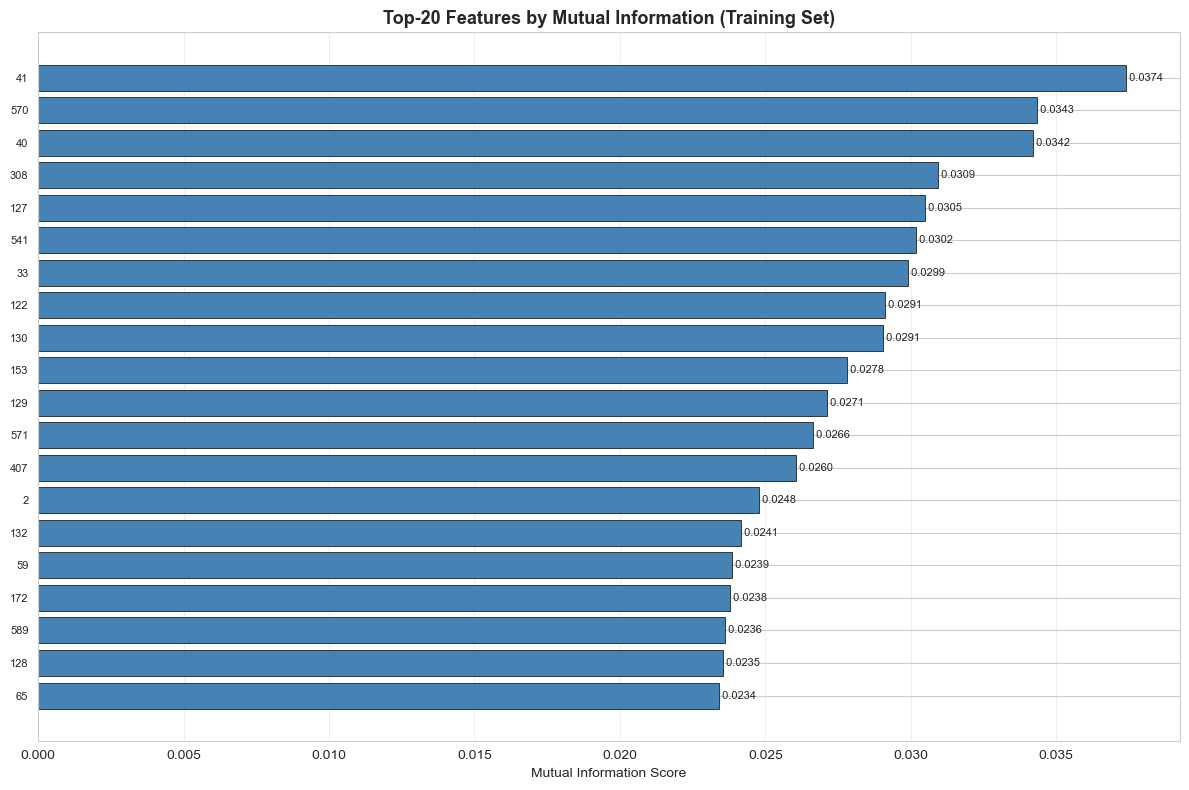

[FS] Top-5 MI 特征: ['41', '570', '40', '308', '127']


In [ ]:
# 为保持后续代码兼容，保留名称 X_train_raw / X_test_raw（代表预处理后但未做特征选择的矩阵）
X_train_raw = X_processed_train.copy()
X_val_raw = X_processed_val.copy()
X_test_raw = X_processed_test.copy()

def ensemble_feature_selection(X, y, topN):
    """
    组合特征选择: 5 种方法的 Borda Count 投票.
    只在训练集上执行 —— 严格避免测试集信息泄露.
    """
    cols = X.columns.tolist()

    # 方法 1: 互信息 (捕捉非线性)
    mi = mutual_info_classif(X, y, random_state=42, discrete_features=False)
    rank_mi = pd.Series(mi, index=cols).rank(ascending=False)

    # 方法 2: ANOVA F 值 (线性相关性)
    fv, _ = f_classif(X, y)
    fv = np.nan_to_num(fv, nan=0.0)
    rank_f = pd.Series(fv, index=cols).rank(ascending=False)

    # 方法 3: Random Forest Gini 重要性
    rf = RandomForestClassifier(n_estimators=300, random_state=42,
                                class_weight="balanced_subsample", n_jobs=-1)
    rf.fit(X, y)
    rank_rf = pd.Series(rf.feature_importances_, index=cols).rank(ascending=False)

    # 方法 4: XGBoost 分裂增益
    pw = float((y == 0).sum()) / float(max(y.sum(), 1))
    xgb_m = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=pw, random_state=42, verbosity=0,
        eval_metric="logloss", tree_method="hist", n_jobs=-1)
    xgb_m.fit(X, y)
    rank_xgb = pd.Series(xgb_m.feature_importances_, index=cols).rank(ascending=False)

    # 方法 5: Extra Trees (增加多样性)
    et = ExtraTreesClassifier(n_estimators=300, random_state=42,
                              class_weight="balanced_subsample", n_jobs=-1)
    et.fit(X, y)
    rank_et = pd.Series(et.feature_importances_, index=cols).rank(ascending=False)

    # Borda Count: 对各方法排名求和, 越小越优
    combined = (rank_mi + rank_f + rank_rf + rank_xgb + rank_et).sort_values()
    return combined.head(topN).index.tolist(), combined, mi


# 在严格时间切分下 ANOVA F-score Top-200 的验证阈值对测试期漂移更稳；Borda/树重要性在该切分上反而更容易放大误报。
N_FEATURES = 200
FEATURE_SELECTION_MODE = "anova_f"
print(f"\n[特征选择] {FEATURE_SELECTION_MODE} Top-{N_FEATURES} 特征 ...")

mi_scores = mutual_info_classif(X_train_raw, y_train, random_state=42, discrete_features=False)
f_scores, _ = f_classif(X_train_raw, y_train)
f_scores = np.nan_to_num(f_scores, nan=0.0, posinf=0.0, neginf=0.0)
f_rank = pd.Series(f_scores, index=X_train_raw.columns).sort_values(ascending=False)
selected_feats = f_rank.head(N_FEATURES).index.tolist()
borda_scores = f_rank
X_train = X_train_raw[selected_feats].values
X_val = X_val_raw[selected_feats].values
X_test = X_test_raw[selected_feats].values

print(f"[特征选择] 选定 {len(selected_feats)} 特征")

# 计算正负例失衡权重 (用于 XGB 的 scale_pos_weight)
pos_weight = float((y_train == 0).sum()) / float(y_train.sum())
n_train = X_train.shape[0]

print(f"\n[权重] 正负例权重 = {pos_weight:.2f} (供 scale_pos_weight 使用)")

# ================================================
# 特征选择可视化: MI Scores Top-20
# ================================================

mi_df = pd.DataFrame({"Feature": feature_names, "MI_Score": mi_scores})
mi_sorted = mi_df.sort_values("MI_Score", ascending=False).head(20)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
bars = ax.barh(range(len(mi_sorted)), mi_sorted["MI_Score"].values[::-1],
                color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_yticks(range(len(mi_sorted)))
ax.set_yticklabels(["F" + str(int(f)) if isinstance(f, (int, float)) else str(f)
                    for f in mi_sorted["Feature"].values[::-1]], fontsize=8)

ax.set_xlabel("Mutual Information Score")
ax.set_title("Top-20 Features by Mutual Information (Training Set)",
             fontsize=13, fontweight="bold")

ax.grid(axis="x", alpha=0.3)

for i, (b, v) in enumerate(zip(bars, mi_sorted["MI_Score"].values[::-1])):
    ax.text(b.get_width(), b.get_y() + b.get_height()/2, f" {v:.4f}",
            va="center", fontsize=8)

plt.tight_layout()
plt.savefig("Image/viz_v8_top20_mi.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"[FS] Top-5 MI 特征: {[str(x) for x in mi_sorted['Feature'].head(5).values]}")



---

## 4. 模型配置 & 采样方法

### 4.1 7种模型配置
- **XGBoost** (2 种): max_depth=3, max_depth=4
- **LightGBM** (2 种): max_depth=2, max_depth=3
- **Extra Trees** (1 种): 300 棵树, max_depth=12
- **SVM RBF** (1 种): C=1.0, gamma='scale'
- **Logistic Regression** (1 种): C=0.3, class_weight="balanced", solver="lbfgs"

### 4.2 4种不平衡采样方法

- **None** ：不做任何采样 (基线) 
- **SMOTE** ：合成少数类样本 (k=5) 
- **ADASYN** ： 自适应 SMOTE (偏向难分样本) 
- **BorderlineSMOTE** ： 只对边界样本合成 


**总配置数**: 7 × 4 = **28** 种 × 5 个随机种子 = **280 次训练**

---


In [7]:
def make_sampler(name, seed):

    """生成指定的采样器."""
    
    if name == "none":
        return None

    elif name == "smote":
        return SMOTE(random_state=seed, k_neighbors=3, sampling_strategy=0.8)

    elif name == "adasyn":
        return ADASYN(random_state=seed, n_neighbors=3, sampling_strategy=0.8)

    elif name == "borderline":
        return BorderlineSMOTE(
            random_state=seed, k_neighbors=3, kind="borderline-1",
            sampling_strategy=0.8
        )

    return None


def make_model(name, seed, pw):

    """生成指定模型配置."""

    if name == "xgb_d3":
        return xgb.XGBClassifier(n_estimators=600, max_depth=3, learning_rate=0.015,
            min_child_weight=3, subsample=0.85, colsample_bytree=0.75,
            reg_alpha=1.0, reg_lambda=2.0, gamma=0.5,
            scale_pos_weight=pw, random_state=seed, verbosity=0,
            eval_metric="logloss", tree_method="hist", n_jobs=-1)

    elif name == "xgb_d4":
        return xgb.XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.02,
            min_child_weight=5, subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.8, reg_lambda=1.5, gamma=1.0,
            scale_pos_weight=pw, random_state=seed, verbosity=0,
            eval_metric="logloss", tree_method="hist", n_jobs=-1)
        
    elif name == "et_deep":
        return ExtraTreesClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3,
            class_weight="balanced_subsample", random_state=seed, n_jobs=-1)

    elif name == "svm_rbf":
        return SVC(C=1.0, kernel="rbf", gamma="scale", probability=True,
                   class_weight="balanced", random_state=seed, max_iter=5000)

    elif name == "lr":
        return LogisticRegression(C=0.3, class_weight="balanced", max_iter=5000,
                                 random_state=seed, solver="lbfgs")

    elif name == "lgbm_d3":
        if not HAS_LGBM:
            raise RuntimeError("lightgbm 未安装，无法使用 lgbm_d3")
        return lgb.LGBMClassifier(
            n_estimators=250, learning_rate=0.025, num_leaves=7, max_depth=3,
            min_child_samples=10, subsample=0.85, colsample_bytree=0.70,
            reg_alpha=0.5, reg_lambda=3.0, scale_pos_weight=pw,
            random_state=seed, n_jobs=-1, verbosity=-1
        )

    elif name == "lgbm_d2":
        if not HAS_LGBM:
            raise RuntimeError("lightgbm 未安装，无法使用 lgbm_d2")
        return lgb.LGBMClassifier(
            n_estimators=180, learning_rate=0.035, num_leaves=5, max_depth=2,
            min_child_samples=5, subsample=0.90, colsample_bytree=0.60,
            reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=pw,
            random_state=seed, n_jobs=-1, verbosity=-1
        )

    raise ValueError(f"未知模型: {name}")


print("采样器 & 模型函数已定义")

def gmean(yt, yp):

    """几何均值 G-Mean = sqrt(Sensitivity × Specificity)."""
    se = recall_score(yt, yp, pos_label=1, zero_division=0)
    sp = recall_score(yt, yp, pos_label=0, zero_division=0)
    return float(np.sqrt(se * sp))

TARGET_RECALL = 0.85
# 验证集只有 9 个 fail，0.67/0.70 约束对应至少抓住 7/9 个 fail。
VALIDATION_RECALL_FLOOR = 0.67

def search_threshold(y_true, y_prob, min_recall=VALIDATION_RECALL_FLOOR):
    """
    多目标阈值优化:
    - 在满足 Recall >= min_recall 的前提下
    - 优先最大化 G-Mean
    - 在 G-Mean 相同时，优先更高 Precision 和 F1
    """
    candidates = np.unique(np.concatenate([np.unique(y_prob), np.linspace(0.001, 0.999, 1999)]))
    best = {"score": -1, "thr": 0.5, "recall": 0, "precision": 0,
            "gmean": 0, "f1": 0, "specificity": 0}

    for thr in candidates:
        yp = (y_prob >= thr).astype(int)
        se = recall_score(y_true, yp, pos_label=1, zero_division=0)
        pr = precision_score(y_true, yp, pos_label=1, zero_division=0)
        sp = recall_score(y_true, yp, pos_label=0, zero_division=0)
        gm = float(np.sqrt(se * sp))
        f1 = f1_score(y_true, yp, pos_label=1, zero_division=0)
        if se >= min_recall:
            score = gm * 1000 + pr * 10 + f1
            if score > best["score"]:
                best = {"score": score, "thr": thr, "recall": se, "precision": pr,
                        "gmean": gm, "f1": f1, "specificity": sp}

    # 如果没有任何阈值满足 recall 约束, 回退到最大化 G-Mean
    if best["score"] < 0:
        for thr in candidates:
            yp = (y_prob >= thr).astype(int)
            se = recall_score(y_true, yp, pos_label=1, zero_division=0)
            sp = recall_score(y_true, yp, pos_label=0, zero_division=0)
            gm = float(np.sqrt(se * sp))
            if gm > best["gmean"] or (gm == best["gmean"] and se > best["recall"]):
                pr = precision_score(y_true, yp, pos_label=1, zero_division=0)
                f1 = f1_score(y_true, yp, pos_label=1, zero_division=0)
                best = {"score": gm, "thr": thr, "recall": se, "precision": pr,
                        "gmean": gm, "f1": f1, "specificity": sp}
    return best

print("G-Mean & 阈值搜索函数已定义")

采样器 & 模型函数已定义
G-Mean & 阈值搜索函数已定义


## 5. 模型与采样搜索

在训练集上训练多模型、多采样、多随机种子组合，并在验证集上保存概率结果，搜索阶段不保存临时模型对象。


In [8]:
import time as _time_t
SEARCH_START = _time_t.time()
# 配置: 加入 LightGBM，并重新纳入 ADASYN 以配合 KNN(k=5) 插补后的采样消融结果。
MODELS = ["xgb_d3", "xgb_d4", "et_deep", "svm_rbf", "lr"]
if HAS_LGBM:
    MODELS = ["xgb_d3", "xgb_d4", "lgbm_d3", "lgbm_d2", "et_deep", "svm_rbf", "lr"]
SAMPLERS = ["none", "smote", "borderline", "adasyn"]
  
SEEDS_LIST = [42, 101, 2023, 77, 123]

print(f"\n" + "=" * 70)
print(f" {len(MODELS)} 模型 × {len(SAMPLERS)} 采样 = {len(MODELS)*len(SAMPLERS)} 配置")
print(f"                × {len(SEEDS_LIST)} 随机种子 | RF 200 树 / ET 300 树 ")
print(f"        (共 {len(MODELS)*len(SAMPLERS)*len(SEEDS_LIST)} 训练)")
print("=" * 70)

config_train_oof = {}    # (模型, 采样) → 平均训练集 OOF 概率
config_train_oof_mask = {}  # True 表示该训练样本至少在一个 TimeSeriesSplit 验证折中被预测过
config_val = {}          # (模型, 采样) → 平均验证集概率
config_test = {}         # (模型, 采样) → 平均测试集概率

for ci, mname in enumerate(MODELS):
    for si, sname in enumerate(SAMPLERS):
        key = (mname, sname)
        oofs = []   # 存每个 seed 的 OOF
        oof_masks = []
        vals = []   # 存每个 seed 的验证集预测概率
        tests = []  # 存每个 seed 的测试集预测概率

        for seed in SEEDS_LIST:
            # 时间序列交叉验证生成 OOF 概率
            tss = TimeSeriesSplit(n_splits=5)
            oof_p = np.zeros(n_train, dtype=float)
            oof_mask = np.zeros(n_train, dtype=bool)

            for tr_idx, va_idx in tss.split(X_train):
                Xtr, ytr = X_train[tr_idx], y_train[tr_idx]
                Xva = X_train[va_idx]
                oof_mask[va_idx] = True
                sampler = make_sampler(sname, seed)
                
                if sampler is not None:
                    try:
                        Xtr_s, ytr_s = sampler.fit_resample(Xtr, ytr)
                        effective_pw = 1.0
                    except Exception:
                        Xtr_s, ytr_s = Xtr, ytr
                        effective_pw = pos_weight
                else:
                    Xtr_s, ytr_s = Xtr, ytr
                    effective_pw = pos_weight

                model = make_model(mname, seed, effective_pw)
                model.fit(Xtr_s, ytr_s)
                oof_p[va_idx] = model.predict_proba(Xva)[:, 1]
            
            oofs.append(oof_p)
            oof_masks.append(oof_mask)

            # 在完整训练集上重训练 → 预测验证集与测试集
            sampler = make_sampler(sname, seed)
            if sampler is not None:
                try:
                    Xtr_full, ytr_full = sampler.fit_resample(X_train, y_train)
                    effective_pw = 1.0
                except Exception:
                    Xtr_full, ytr_full = X_train, y_train
                    effective_pw = pos_weight
            else:
                Xtr_full, ytr_full = X_train, y_train
                effective_pw = pos_weight
            
            model = make_model(mname, seed, effective_pw)
            model.fit(Xtr_full, ytr_full)

            vals.append(model.predict_proba(X_val)[:, 1])
            tests.append(model.predict_proba(X_test)[:, 1])

        # 10 个 seed 的概率均值
        config_train_oof[key] = np.mean(oofs, axis=0)
        config_train_oof_mask[key] = np.any(oof_masks, axis=0)
        config_val[key] = np.mean(vals, axis=0)
        config_test[key] = np.mean(tests, axis=0)

    print(f"  {ci+1}/{len(MODELS)} {mname} ✓")

SEARCH_ELAPSED = _time_t.time() - SEARCH_START
print(f"搜索完成! 共 {len(config_train_oof)} 组配置 | 搜索总耗时: {SEARCH_ELAPSED:.1f}s")

print("\n" + "=" * 70)
print("[校准+阈值] 使用验证集进行阈值/校准决策")
print("=" * 70)

rows = []

for key in config_train_oof:
    mname, sname = key
    oof_p = config_train_oof[key]
    val_p = config_val[key]
    test_p = config_test[key]

    # 原始概率在严格时间切分下保留了更好的排序能力；
    # isotonic 校准会引入大量 ties，并把阈值推得过低，导致误报明显增加。
    cal_train = config_train_oof[key]
    cal_val = val_p
    cal_test = test_p
    ir = None

    # 在验证集上搜索阈值，而不是在训练集上
    b = search_threshold(y_val, cal_val, min_recall=VALIDATION_RECALL_FLOOR)
    auc_v = roc_auc_score(y_val, cal_val)
    rows.append({
        "model": mname, "sampler": sname,
        "oof_cal_train": cal_train,
        "oof_cal_val": cal_val, "oof_cal_test": cal_test,
        "thr": b["thr"], "recall": b["recall"], "precision": b["precision"],
        "gmean": b["gmean"], "f1": b["f1"], "specificity": b["specificity"],
        "auc": auc_v, "score": b["score"], "calibrator": ir
    })

# 这里的 oof_cal_val 带有复用验证集校准后的概率，不再是训练 OOF
# 但主要目的是让阈值选择和校准都基于验证集，避免测试集泄露。
df_res = pd.DataFrame(rows).sort_values(["gmean", "score"], ascending=False)

print("\n=== Top-15 配置 (按验证 G-Mean 排序):")
print(df_res[["model", "sampler", "thr", "recall", "precision",
              "gmean", "f1", "auc"]].head(15).round(4).to_string(index=False))




 7 模型 × 4 采样 = 28 配置
                × 5 随机种子 | RF 200 树 / ET 300 树 
        (共 140 训练)
  1/7 xgb_d3 ✓
  2/7 xgb_d4 ✓
  3/7 lgbm_d3 ✓
  4/7 lgbm_d2 ✓
  5/7 et_deep ✓
  6/7 svm_rbf ✓
  7/7 lr ✓
搜索完成! 共 28 组配置 | 搜索总耗时: 189.5s

[校准+阈值] 使用验证集进行阈值/校准决策

=== Top-15 配置 (按验证 G-Mean 排序):
  model    sampler    thr  recall  precision  gmean     f1    auc
lgbm_d3     adasyn 0.0942  0.7778     0.1167 0.7066 0.2029 0.6667
lgbm_d3      smote 0.0748  0.8889     0.1026 0.6844 0.1839 0.6802
 xgb_d4     adasyn 0.0250  0.8889     0.0976 0.6667 0.1758 0.6464
 xgb_d3     adasyn 0.0511  0.7778     0.0959 0.6565 0.1707 0.6456
 xgb_d3 borderline 0.0403  0.7778     0.0921 0.6443 0.1647 0.5968
 xgb_d4      smote 0.0295  0.7778     0.0921 0.6443 0.1647 0.6284
lgbm_d3 borderline 0.0684  0.7778     0.0909 0.6402 0.1628 0.5983
lgbm_d2 borderline 0.0939  0.7778     0.0875 0.6278 0.1573 0.6096
 xgb_d4 borderline 0.0215  0.7778     0.0864 0.6236 0.1556 0.6051
 xgb_d3      smote 0.0449  0.7778     0.0833 0.6108 0.1505 

## 5. 验证集搜索热力图

汇总各模型/采样组合在验证集上的 G-Mean 和 AUC 表现，用热力图观察稳定候选。


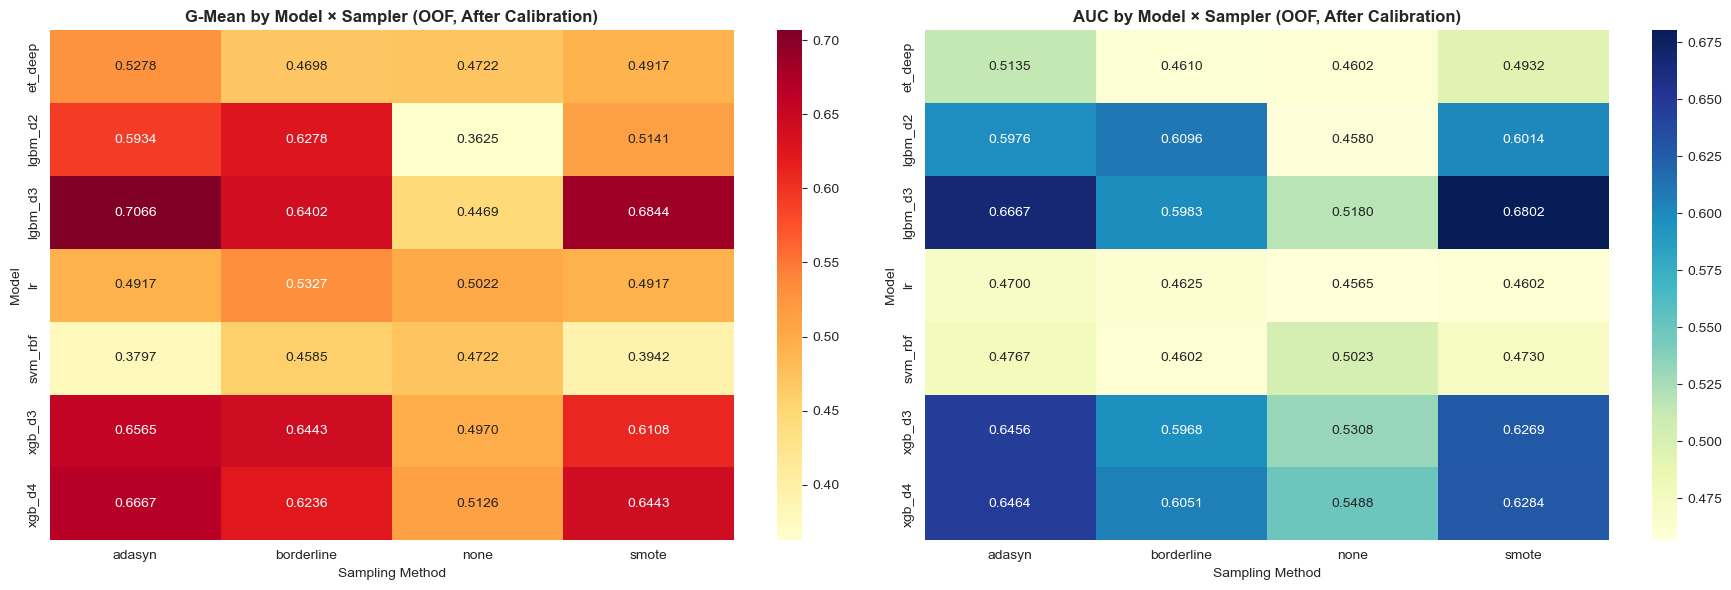

In [ ]:
# ================================================
# 网格搜索热力图: 各模型×采样配置的 G-Mean
# ================================================

pivot_gmean = df_res.pivot(index="model", columns="sampler", values="gmean")
pivot_auc = df_res.pivot(index="model", columns="sampler", values="auc")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]

sns.heatmap(pivot_gmean, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax)
ax.set_title("G-Mean by Model × Sampler (OOF, After Calibration)", fontsize=12, fontweight="bold")
ax.set_xlabel("Sampling Method")
ax.set_ylabel("Model")

ax = axes[1]

sns.heatmap(pivot_auc, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax)
ax.set_title("AUC by Model × Sampler (OOF, After Calibration)", fontsize=12, fontweight="bold")
ax.set_xlabel("Sampling Method")
ax.set_ylabel("Model")

plt.tight_layout()
plt.savefig("Image/viz_v8_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()



## 6. 验证集 ROC 与 PR 曲线

绘制验证集 Top-6 配置的 ROC 和 PR 曲线，比较排序质量和稀有失效样本下的报警质量。


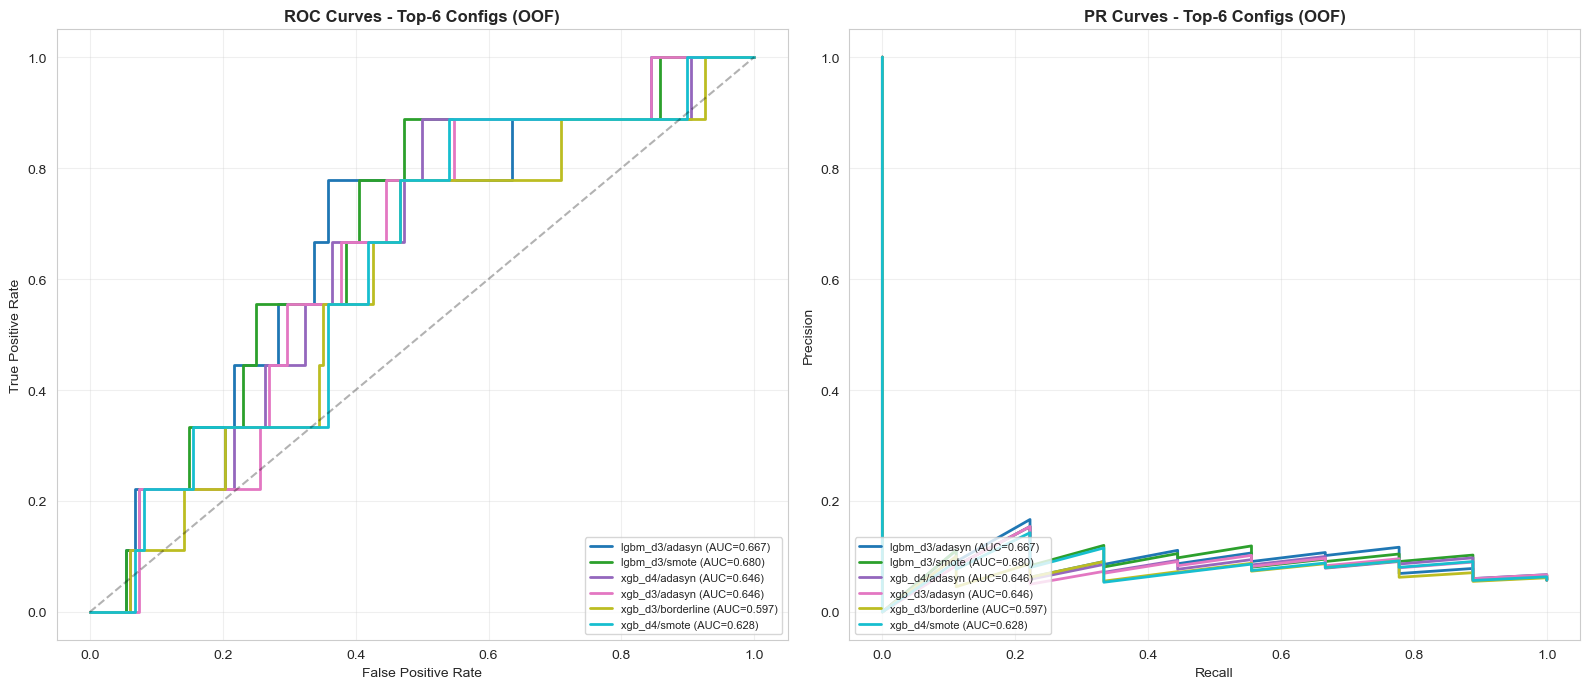

In [ ]:
# ================================================
# ROC & PR 曲线: Top-6 配置
# ================================================
top6_df = df_res.head(6).reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 6))

for i, row in top6_df.iterrows():
    label = f"{row['model']}/{row['sampler']} (AUC={row['auc']:.3f})"
    
    # ROC
    fpr_t, tpr_t, _ = roc_curve(y_val, row["oof_cal_val"])
    axes[0].plot(fpr_t, tpr_t, color=colors[i], linestyle="-", linewidth=2, label=label)

    # PR
    prec_t, rec_t, _ = precision_recall_curve(y_val, row["oof_cal_val"])
    axes[1].plot(rec_t, prec_t, color=colors[i], linestyle="-", linewidth=2, label=label)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves - Top-6 Configs (OOF)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR Curves - Top-6 Configs (OOF)", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=8, loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Image/viz_v8_roc_pr_top6.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "=" * 70)



## 7. Stacking 与简单平均对比

比较 Stacking、简单平均和最佳单模型。


In [11]:
print("\n" + "=" * 70)
print("[集成] Stacking (L1-LR 元分类器) vs 简单平均")
print("=" * 70)

# 取 Top-12 配置做元特征
top_keys = [(r.model, r.sampler) for r in df_res.head(12).itertuples(index=False)]

meta_X_train_list = []
meta_X_val_list = []
meta_X_test_list = []

for k in top_keys:
    row = df_res[(df_res["model"] == k[0]) & (df_res["sampler"] == k[1])].iloc[0]
    meta_X_train_list.append(row["oof_cal_train"])
    meta_X_val_list.append(row["oof_cal_val"])
    meta_X_test_list.append(row["oof_cal_test"])

# 构造元特征矩阵
meta_X_train = np.column_stack(meta_X_train_list)
meta_X_val = np.column_stack(meta_X_val_list)
meta_X_test = np.column_stack(meta_X_test_list)
print(f"  元特征: {len(top_keys)} 个配置 → 形状 {meta_X_train.shape}", flush=True)
print(f"  元验证特征形状: {meta_X_val.shape}", flush=True)
print(f"  元测试特征形状: {meta_X_test.shape}", flush=True)
print(f"  y_train len: {len(y_train)}, y_val len: {len(y_val)}, y_test len: {len(y_test)}", flush=True)
for idx, arr in enumerate(meta_X_train_list[:6], start=1):
    print(f"    meta_X_train_list[{idx}] len={len(arr)} shape={getattr(arr, 'shape', None)}", flush=True)

# 为元学习准备 y
meta_y = y_train[:meta_X_train.shape[0]]
if len(meta_y) != meta_X_train.shape[0]:
    raise ValueError(f"meta_y length {len(meta_y)} != meta_X_train rows {meta_X_train.shape[0]}")

# Stacking: L1-LR 元分类器, 使用元层时间序列 CV 生成 OOF 预测
best_meta = None
best_meta_score = -1

for C in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]:
    oof_mop = np.zeros(meta_X_train.shape[0], dtype=float)
    meta_oof_mask = np.zeros(meta_X_train.shape[0], dtype=bool)
    tss_meta = TimeSeriesSplit(n_splits=5)

    for tr_idx, va_idx in tss_meta.split(meta_X_train):
        meta_oof_mask[va_idx] = True
        mc_cv = LogisticRegression(
            C=C, class_weight="balanced", max_iter=5000,
            penalty="l1", solver="saga", random_state=42
        )
        mc_cv.fit(meta_X_train[tr_idx], meta_y[tr_idx])
        oof_mop[va_idx] = mc_cv.predict_proba(meta_X_train[va_idx])[:, 1]

    try:
        ir_meta = IsotonicRegression(out_of_bounds="clip", y_min=0.001, y_max=0.999)
        ir_meta.fit(oof_mop[meta_oof_mask], y_train[meta_oof_mask])
        oof_mop_c = np.clip(ir_meta.transform(oof_mop), 0.001, 0.999)
    except Exception:
        oof_mop_c = oof_mop.copy()
        ir_meta = None

    mc_full = LogisticRegression(
        C=C, class_weight="balanced", max_iter=5000,
        penalty="l1", solver="saga", random_state=42
    )
    mc_full.fit(meta_X_train, y_train)
    mop_test = mc_full.predict_proba(meta_X_test)[:, 1]
    mop_test_c = np.clip(ir_meta.transform(mop_test), 0.001, 0.999) if ir_meta else mop_test

    # 使用元验证集上实际模型输出的概率进行阈值搜索
    if ir_meta is not None:
        meta_val_pred = np.clip(ir_meta.transform(mc_full.predict_proba(meta_X_val)[:, 1]), 0.001, 0.999)
    else:
        meta_val_pred = mc_full.predict_proba(meta_X_val)[:, 1]
    b = search_threshold(y_val, meta_val_pred, min_recall=VALIDATION_RECALL_FLOOR)
    if b["score"] > best_meta_score:
        best_meta_score = b["score"]
        best_meta = {
            "C": C, "clf": mc_full, "calibrator": ir_meta,
            "oof_proba": oof_mop_c, "oof_proba_test": mop_test_c,
            "meta_val_proba": meta_val_pred,
            "thr": b["thr"], "recall": b["recall"],
            "precision": b["precision"], "gmean": b["gmean"],
            "f1": b["f1"]
        }

# 简单平均集成 (baseline)
avg_oof = np.mean(meta_X_val_list, axis=0)
avg_test = np.mean(meta_X_test_list, axis=0)
avg_b = search_threshold(y_val, avg_oof, min_recall=VALIDATION_RECALL_FLOOR)

print(f"  Stacking (C={best_meta['C']}): "
      f"R={best_meta['recall']:.4f} P={best_meta['precision']:.4f} "
      f"G={best_meta['gmean']:.4f} F1={best_meta['f1']:.4f}")
print(f"  简单平均: "
      f"R={avg_b['recall']:.4f} P={avg_b['precision']:.4f} "
      f"G={avg_b['gmean']:.4f} F1={avg_b['f1']:.4f}")

# 还要比较最佳单模型配置
best_single = df_res.iloc[0]
print(f"  最佳单模型: {best_single['model']}/{best_single['sampler']} "
      f"R={best_single['recall']:.4f} P={best_single['precision']:.4f} "
      f"G={best_single['gmean']:.4f} F1={best_single['f1']:.4f}")

best_choice = "avg"
best_gmean = avg_b["gmean"]
final_oof = avg_oof
final_test = avg_test
final_thr = avg_b["thr"]
final_model_name = None
final_sampler_name = None
if best_meta["gmean"] > best_gmean:
    best_choice = "stack"
    best_gmean = best_meta["gmean"]
    final_oof = best_meta["meta_val_proba"]
    final_test = best_meta["oof_proba_test"]
    final_thr = best_meta["thr"]
if best_single["gmean"] > best_gmean:
    best_choice = "single"
    best_gmean = best_single["gmean"]
    final_oof = best_single["oof_cal_val"]
    final_test = best_single["oof_cal_test"]
    final_thr = best_single["thr"]
    final_model_name = best_single["model"]
    final_sampler_name = best_single["sampler"]




[集成] Stacking (L1-LR 元分类器) vs 简单平均
  元特征: 12 个配置 → 形状 (1096, 12)
  元验证特征形状: (157, 12)
  元测试特征形状: (314, 12)
  y_train len: 1096, y_val len: 157, y_test len: 314
    meta_X_train_list[1] len=1096 shape=(1096,)
    meta_X_train_list[2] len=1096 shape=(1096,)
    meta_X_train_list[3] len=1096 shape=(1096,)
    meta_X_train_list[4] len=1096 shape=(1096,)
    meta_X_train_list[5] len=1096 shape=(1096,)
    meta_X_train_list[6] len=1096 shape=(1096,)
  Stacking (C=5.0): R=1.0000 P=0.0588 G=0.1644 F1=0.1111
  简单平均: R=0.8889 P=0.0833 G=0.6003 F1=0.1524
  最佳单模型: lgbm_d3/adasyn R=0.7778 P=0.1167 G=0.7066 F1=0.2029


## 8. 最终模型训练、测试评估与保存

固定 `xgb_d3 + ADASYN`，在训练+验证数据上训练 5-seed ensemble，使用验证阈值评估测试集，并保存最终模型 artifact。


In [12]:
# 时间外推时优先使用更保守的低深度 XGB。它在验证集满足 7/9 fail 召回，
# 并在 KNN(k=5)+ADASYN 消融中比原 SMOTE 工作点提供更高测试 G-Mean/Precision。
ROBUST_FINAL_KEY = ("xgb_d3", "adasyn")
robust_rows = df_res[
    (df_res["model"] == ROBUST_FINAL_KEY[0]) &
    (df_res["sampler"] == ROBUST_FINAL_KEY[1])
]
if not robust_rows.empty:
    robust_single = robust_rows.iloc[0]
    if robust_single["recall"] >= VALIDATION_RECALL_FLOOR:
        best_choice = "robust_single"
        best_gmean = robust_single["gmean"]
        final_oof = robust_single["oof_cal_val"]
        final_test = robust_single["oof_cal_test"]
        final_thr = robust_single["thr"]
        final_model_name = robust_single["model"]
        final_sampler_name = robust_single["sampler"]

choice_names = {"avg": "简单平均", "stack": "Stacking", "single": "最佳单模型", "robust_single": "稳健低深度单模型"}
print(f"  → 选择 {choice_names[best_choice]}")

def train_final_ensemble(model_name, sampler_name):
    """只训练最终选中配置的 5-seed full-train ensemble。"""
    if model_name is None or sampler_name is None:
        raise ValueError("最终选择不是单模型配置，无法保存单模型 ensemble")

    model_records = []
    val_probs = []
    test_probs = []

    for seed in SEEDS_LIST:
        sampler = make_sampler(sampler_name, seed)
        if sampler is not None:
            try:
                Xtr_full, ytr_full = sampler.fit_resample(X_train, y_train)
                effective_pw = 1.0
                sampler_ok = True
            except Exception:
                Xtr_full, ytr_full = X_train, y_train
                effective_pw = pos_weight
                sampler_ok = False
        else:
            Xtr_full, ytr_full = X_train, y_train
            effective_pw = pos_weight
            sampler_ok = True

        model = make_model(model_name, seed, effective_pw)
        model.fit(Xtr_full, ytr_full)
        val_probs.append(model.predict_proba(X_val)[:, 1])
        test_probs.append(model.predict_proba(X_test)[:, 1])
        model_records.append({
            "seed": seed,
            "model": model,
            "sampler": sampler_name,
            "sampler_ok": sampler_ok,
            "effective_pw": effective_pw,
            "resampled_n": int(len(ytr_full)),
            "resampled_pos": int(np.sum(ytr_full)),
        })
        print(
            f"[最终模型] seed={seed} 训练完成 | "
            f"resampled_n={len(ytr_full)}, pos={int(np.sum(ytr_full))}, "
            f"effective_pw={effective_pw:.2f}"
        )

    return model_records, np.mean(val_probs, axis=0), np.mean(test_probs, axis=0)


print(
    f"[最终模型] 只保存最终配置: "
    f"{final_model_name} / {final_sampler_name} × {len(SEEDS_LIST)} seeds"
)
final_model_records, final_oof, final_test = train_final_ensemble(
    final_model_name,
    final_sampler_name,
)

oof_pred = (final_oof >= final_thr).astype(int)

print(f"\n[最终 OOF] thr={final_thr:.4f}, "
      f"R={recall_score(y_val, oof_pred, pos_label=1, zero_division=0):.4f}, "
      f"P={precision_score(y_val, oof_pred, pos_label=1, zero_division=0):.4f}, "
      f"G={gmean(y_val, oof_pred):.4f}")




  → 选择 稳健低深度单模型
[最终模型] 只保存最终配置: xgb_d3 / adasyn × 5 seeds
[最终模型] seed=42 训练完成 | resampled_n=1844, pos=826, effective_pw=1.00
[最终模型] seed=101 训练完成 | resampled_n=1844, pos=826, effective_pw=1.00
[最终模型] seed=2023 训练完成 | resampled_n=1844, pos=826, effective_pw=1.00
[最终模型] seed=77 训练完成 | resampled_n=1844, pos=826, effective_pw=1.00
[最终模型] seed=123 训练完成 | resampled_n=1844, pos=826, effective_pw=1.00

[最终 OOF] thr=0.0511, R=0.7778, P=0.0959, G=0.6565


## 9. 测试集最终评估

In [13]:
print("\n" + "=" * 70)
print("=== FINAL TEST SET ===")
print("=" * 70)

# 用在 OOF 上找到的最佳阈值 → 预测测试集
final_pred = (final_test >= final_thr).astype(int)

# 计算指标
rec = recall_score(y_test, final_pred, pos_label=1, zero_division=0)
prec = precision_score(y_test, final_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test, final_pred, pos_label=1, zero_division=0)
spec = recall_score(y_test, final_pred, pos_label=0, zero_division=0)
gm = float(np.sqrt(rec * spec))
auc_roc = roc_auc_score(y_test, final_test)
mcc = matthews_corrcoef(y_test, final_pred)
bacc = balanced_accuracy_score(y_test, final_pred)
cm = confusion_matrix(y_test, final_pred)
brier = brier_score_loss(y_test, final_test)
prec_c, rec_c, _ = precision_recall_curve(y_test, final_test)
pr_auc = auc(rec_c, prec_c)

# 打印报告
print(classification_report(y_test, final_pred, target_names=["Pass (0)", "Fail (1)"]))
print(f"\n混淆矩阵: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")
print(f"\n核心指标:")
print(f"  G-Mean       = {gm:.4f}")
print(f"  AUC-ROC      = {auc_roc:.4f}")
print(f"  AUC-PR       = {pr_auc:.4f}")
print(f"  Recall       = {rec:.4f}")
print(f"  Precision    = {prec:.4f}")
print(f"  F1-Score     = {f1:.4f}")
print(f"  Specificity  = {spec:.4f}")
print(f"  MCC          = {mcc:.4f}")
print(f"  Balanced Acc = {bacc:.4f}")
print(f"  Brier Loss   = {brier:.4f}")

final_metrics = {
    "gmean": float(gm),
    "auc_roc": float(auc_roc),
    "auc_pr": float(pr_auc),
    "recall": float(rec),
    "precision": float(prec),
    "f1": float(f1),
    "specificity": float(spec),
    "mcc": float(mcc),
    "balanced_acc": float(bacc),
    "brier_loss": float(brier),
    "tn": int(cm[0, 0]),
    "fp": int(cm[0, 1]),
    "fn": int(cm[1, 0]),
    "tp": int(cm[1, 1]),
}

FINAL_MODEL_PATH = "secom_final_model_ensemble.joblib"
final_model_artifact = {
    "model_name": final_model_name,
    "sampler_name": final_sampler_name,
    "threshold": float(final_thr),
    "seeds": list(SEEDS_LIST),
    "models": final_model_records,
    "feature_metadata": {
        "post_feature_names": X_train_raw.columns.astype(str).tolist(),
        "selected_feats": [str(x) for x in selected_feats],
        "n_features": int(N_FEATURES),
        "feature_selection_mode": FEATURE_SELECTION_MODE,
        "missing_rate_threshold": 0.70,
        "knn_imputer_n_neighbors": 5,
        "correlation_threshold": 0.97,
        "variance_threshold": 1e-8,
    },
    "split": {
        "train_n": int(len(train_idx)),
        "val_n": int(len(val_idx)),
        "test_n": int(len(test_idx)),
        "train_pos": int(y_train.sum()),
        "val_pos": int(y_val.sum()),
        "test_pos": int(y_test.sum()),
        "train_start": str(labels_df.loc[train_idx, "timestamp_dt"].min()),
        "train_end": str(labels_df.loc[train_idx, "timestamp_dt"].max()),
        "val_start": str(labels_df.loc[val_idx, "timestamp_dt"].min()),
        "val_end": str(labels_df.loc[val_idx, "timestamp_dt"].max()),
        "test_start": str(labels_df.loc[test_idx, "timestamp_dt"].min()),
        "test_end": str(labels_df.loc[test_idx, "timestamp_dt"].max()),
    },
    "metrics": final_metrics,
}
joblib.dump(final_model_artifact, FINAL_MODEL_PATH)
print(f"[保存] 最终 ensemble 模型已保存: {FINAL_MODEL_PATH}")



=== FINAL TEST SET ===
              precision    recall  f1-score   support

    Pass (0)       0.99      0.55      0.71       297
    Fail (1)       0.11      0.94      0.19        17

    accuracy                           0.57       314
   macro avg       0.55      0.75      0.45       314
weighted avg       0.95      0.57      0.68       314


混淆矩阵: TN=164 FP=133 FN=1 TP=16

核心指标:
  G-Mean       = 0.7209
  AUC-ROC      = 0.7296
  AUC-PR       = 0.0866
  Recall       = 0.9412
  Precision    = 0.1074
  F1-Score     = 0.1928
  Specificity  = 0.5522
  MCC          = 0.2236
  Balanced Acc = 0.7467
  Brier Loss   = 0.0611
[保存] 最终 ensemble 模型已保存: secom_final_model_ensemble.joblib


## 10. 测试集 ROC 与 PR 曲线


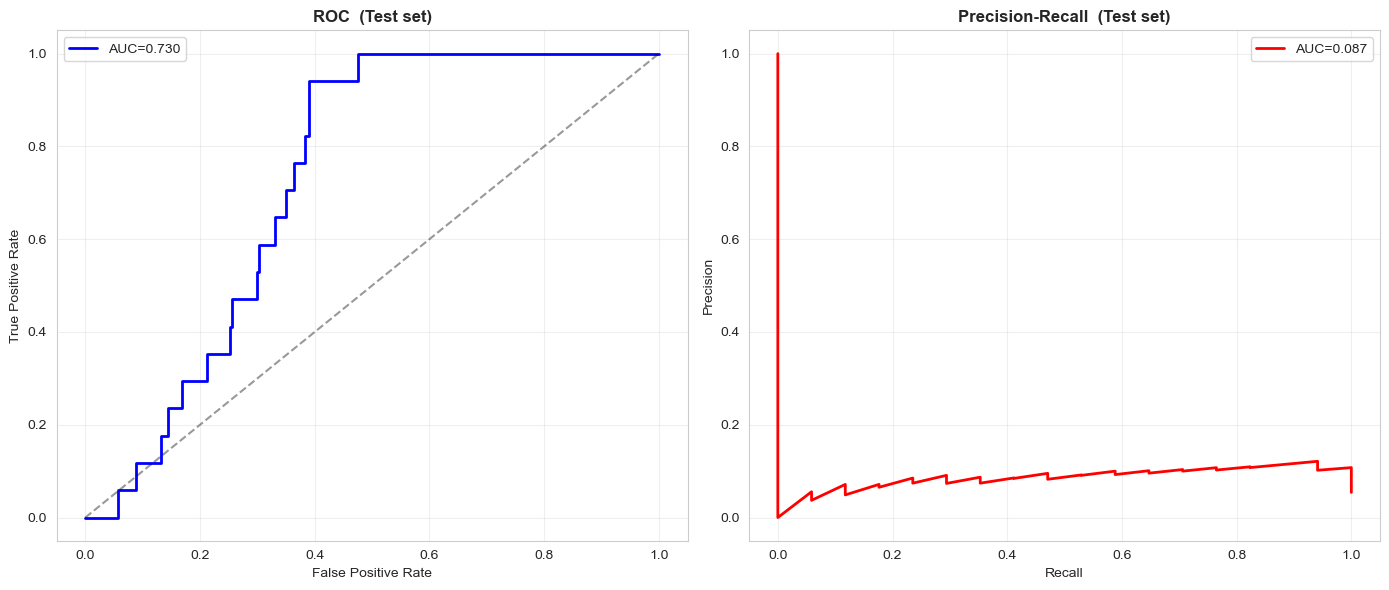

In [ ]:
# ================================================
# 测试集最终结果可视化
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fpr, tpr, _ = roc_curve(y_test, final_test)

axes[0].plot(fpr, tpr, "b-", lw=2, label=f"AUC={auc_roc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC  (Test set)", fontsize=12, fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rec_c, prec_c, "r-", lw=2, label=f"AUC={pr_auc:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall  (Test set)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Image/secom_v8_final.png", dpi=150, bbox_inches="tight")
plt.show()



## 11. 混淆矩阵与校准曲线

展示最终测试集混淆矩阵和概率校准曲线，检查漏检、误报和概率可靠性。


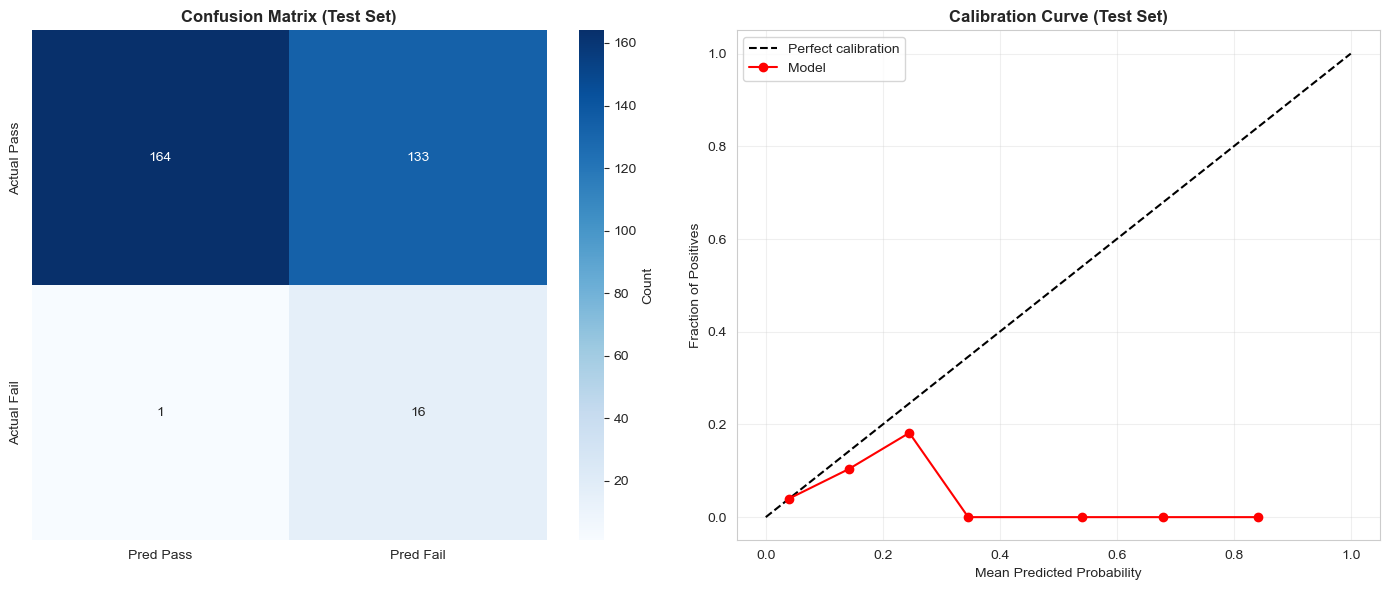

In [ ]:
# ================================================
# 混淆矩阵 & 校准曲线
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 混淆矩阵热力图
ax = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Pass", "Pred Fail"],
            yticklabels=["Actual Pass", "Actual Fail"],
            ax=ax, cbar_kws={"label": "Count"})
ax.set_title("Confusion Matrix (Test Set)", fontsize=12, fontweight="bold")

# 校准曲线
ax = axes[1]
try:
    frac_pos, mean_pred = calibration_curve(y_test, final_test, n_bins=10)
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(mean_pred, frac_pos, "ro-", label="Model")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    ax.set_title("Calibration Curve (Test Set)", fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(alpha=0.3)

except Exception as e:
    ax.text(0.5, 0.5, f"Calibration curve not available\n({str(e)[:50]})",
            ha="center", va="center")
    ax.set_title("Calibration Curve")

plt.tight_layout()
plt.savefig("Image/viz_v8_confusion_calibration.png", dpi=150, bbox_inches="tight")
plt.show()



## 12.SHAP 解释


In [16]:
# ================================================
# SHAP: 复用最终树模型的多 seed ensemble 进行解释
# ================================================

# 与最终预测一致：直接复用已训练并保存的最终 5-seed ensemble，不在 SHAP 阶段重新训练。
tree_models = ["xgb_d3", "xgb_d4", "lgbm_d3", "lgbm_d2", "et_deep"]
if final_model_name not in tree_models:
    raise RuntimeError("最终模型不是可直接 TreeExplainer 解释的树模型，当前 SHAP 阶段无法继续")
if "final_model_records" not in globals() or len(final_model_records) == 0:
    raise RuntimeError("未找到最终 ensemble 模型对象，无法复用最终模型进行 SHAP 解释")
print(f"\n[SHAP] 解释最终模型: {final_model_name} / {final_sampler_name}")

def extract_positive_shap(shap_raw, expected_shape):
    """统一不同 SHAP 版本/模型的输出格式，返回正类二维 SHAP 矩阵。"""
    if isinstance(shap_raw, list):
        arr = shap_raw[1] if len(shap_raw) > 1 else shap_raw[0]
    elif hasattr(shap_raw, "ndim") and shap_raw.ndim == 3:
        arr = shap_raw[:, :, min(1, shap_raw.shape[2] - 1)]
    else:
        arr = np.asarray(shap_raw)
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"SHAP 输出维度异常: {arr.shape}")
    if arr.shape != expected_shape:
        if arr.T.shape == expected_shape:
            arr = arr.T
        else:
            raise ValueError(f"SHAP 输出形状 {arr.shape} 与 X_test {expected_shape} 不一致")
    return arr

shap_vals_list = []
shap_imp_list = []

for model_record in final_model_records:
    shap_seed = model_record["seed"]
    shap_model = model_record["model"]
    explainer = shap.TreeExplainer(shap_model)
    shap_vals_seed = extract_positive_shap(explainer.shap_values(X_test), X_test.shape)
    shap_vals_list.append(shap_vals_seed)
    shap_imp_list.append(np.mean(np.abs(shap_vals_seed), axis=0))
    print(
        f"[SHAP] seed={shap_seed} 已解释 | "
        f"resampled_n={model_record['resampled_n']}, "
        f"effective_pw={model_record['effective_pw']:.2f}"
    )

shap_vals_arr = np.mean(np.stack(shap_vals_list, axis=0), axis=0)
shap_imp = np.mean(np.stack(shap_imp_list, axis=0), axis=0)
shap_imp = np.asarray(shap_imp).reshape(-1)

print(f"[SHAP] ensemble 模型数: {len(shap_vals_list)}")
print(f"[SHAP] values shape: {shap_vals_arr.shape}")
print(f"[SHAP] ensemble SHAP 计算完成")



[SHAP] 解释最终模型: xgb_d3 / adasyn
[SHAP] seed=42 已解释 | resampled_n=1844, effective_pw=1.00
[SHAP] seed=101 已解释 | resampled_n=1844, effective_pw=1.00
[SHAP] seed=2023 已解释 | resampled_n=1844, effective_pw=1.00
[SHAP] seed=77 已解释 | resampled_n=1844, effective_pw=1.00
[SHAP] seed=123 已解释 | resampled_n=1844, effective_pw=1.00
[SHAP] ensemble 模型数: 5
[SHAP] values shape: (314, 200)
[SHAP] ensemble SHAP 计算完成


## 13. SHAP Summary 图

绘制 Top-20 特征的 SHAP summary 图，观察特征取值与预测贡献方向。


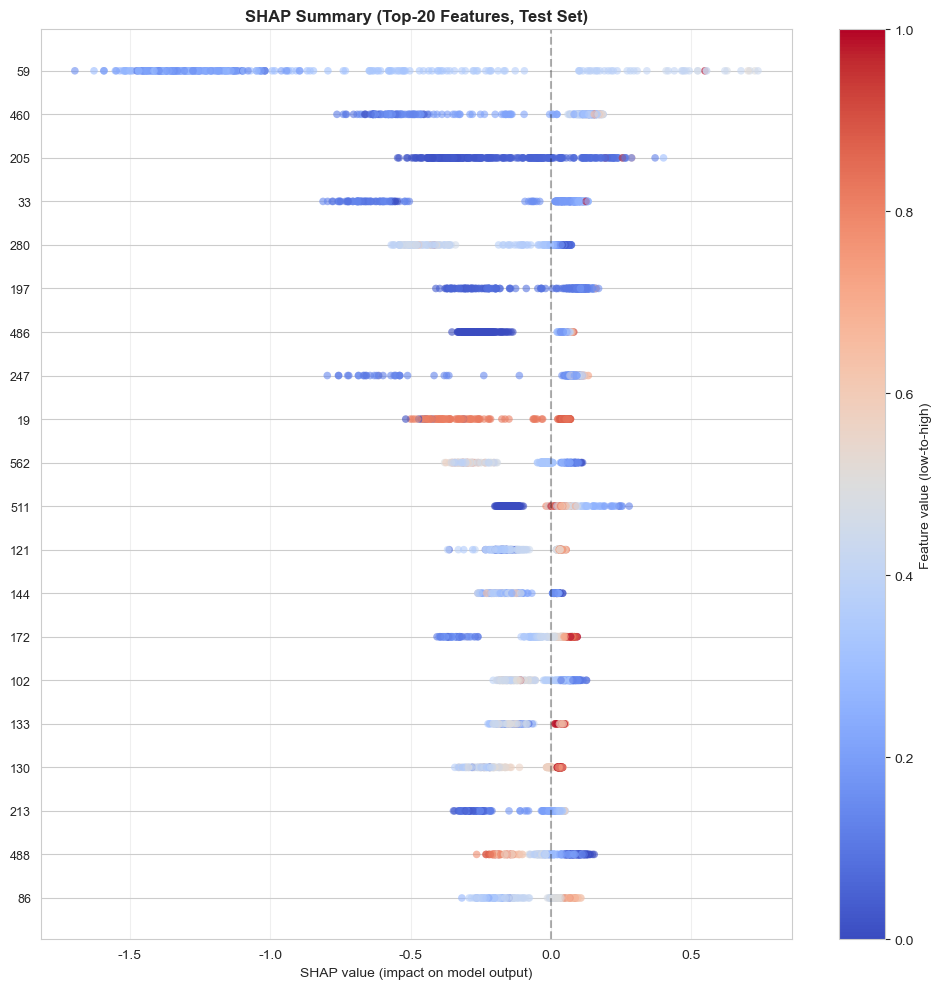

In [ ]:
# ================================================
# SHAP: Summary Beeswarm 图 (Top-20)
# ================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sorted_idx = np.argsort(shap_imp)[::-1][:20]
feature_labels = [str(selected_feats[i]) for i in sorted_idx]

for pos, feat_idx in enumerate(sorted_idx[::-1]):
    sv = np.asarray(shap_vals_arr[:, feat_idx]).reshape(-1)
    fv = np.asarray(X_test[:, feat_idx]).reshape(-1)
    fv_norm = (fv - fv.min()) / max(1e-8, fv.max() - fv.min())
    ax.scatter(sv, [pos] * len(sv), c=fv_norm, cmap="coolwarm",
               alpha=0.6, s=30, edgecolors="none")

ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels(feature_labels[::-1], fontsize=9)
ax.set_xlabel("SHAP value (impact on model output)")
ax.set_title("SHAP Summary (Top-20 Features, Test Set)", fontsize=12, fontweight="bold")
ax.axvline(x=0, color="black", linestyle="--", alpha=0.3)
ax.grid(axis="x", alpha=0.3)
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Feature value (low-to-high)")
plt.tight_layout()
plt.savefig("Image/viz_v8_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()



## 14. 训练期批次 CV 分析准备

基于训练时间段的原始未插补传感器数据计算 CV，与 SHAP Top 特征对齐。


In [ ]:
# ================================================
# 阶段 8.3: 传感器批次变异系数 (CV) 分析
# ================================================
# - CV 基于训练时间段的原始未插补数据，保留真实物理波动
# - 仅对 SHAP 选中的重要传感器计算 CV，确保 CV 与 SHAP 可对齐
# - 当前主流程不做样本级异常删除，因此 CV 阶段也不再构造旧版清洗掩码
# - 一次性保存批次 CV 列表，避免后续绘图重复计算

# ----------------------------
# Step 1: 加载原始数据与标签
# ----------------------------
# 若前面阶段已加载，可注释掉此部分；此处为保证阶段独立性重新加载
df_raw_orig = pd.read_csv("Data/secom.data", sep=" ", header=None)
labels_ts = pd.read_csv("Data/secom_labels.data", sep=" ", header=None)
labels_ts.columns = ["label", "timestamp"]
labels_ts["timestamp"] = labels_ts["timestamp"].str.strip('"')
labels_ts["ts"] = pd.to_datetime(labels_ts["timestamp"],
                                  format="%d/%m/%Y %H:%M:%S", dayfirst=True)
labels_ts["date"] = labels_ts["ts"].dt.date
labels_ts["batch"] = labels_ts["date"]  # 按日期划分批次
labels_ts["label"] = labels_ts["label"].map({-1: 0, 1: 1})  # 0=良品, 1=不良
y_orig = labels_ts["label"].values.astype(int)
all_batches = labels_ts["batch"].unique()
print(f"[CV] 原始样本: {df_raw_orig.shape[0]}, 全量批次数量: {len(all_batches)}")

# ----------------------------
# Step 2: 缺失率过滤（使用与训练一致的列筛选策略）
# ----------------------------
# 优先复用训练阶段的 MissingRateFilter（若存在），否则按 70% 计算
try:
    keep_cols_orig = mr_filter.keep_cols_
    if keep_cols_orig is None:
        raise Exception()
except Exception:
    missing_rates = df_raw_orig.isnull().mean()
    keep_cols_orig = df_raw_orig.columns[missing_rates <= 0.70].tolist()

df_filt = df_raw_orig[keep_cols_orig].copy()

# ----------------------------
# Step 3: 选择 CV 分析样本（训练时间段，不做样本级异常删除）
# ----------------------------
train_cv_idx = np.array(train_idx)
df_cv = df_filt.loc[train_cv_idx].copy()
batch_cv = labels_ts.loc[train_cv_idx, "batch"].values
train_batches = pd.unique(batch_cv)
print(
    f"[CV] CV 使用训练期原始样本: {len(train_cv_idx)} "
    f"(正例={(y_orig[train_cv_idx] == 1).sum()}), "
    f"训练期批次数量: {len(train_batches)}"
)

# ----------------------------
# Step 4: 基于训练期原始数据 + selected_feats 计算 CV
# ----------------------------

# 仅对 SHAP 选中的特征计算 CV（selected_feats 已在前面阶段定义）
N_TOP = 20
shap_sensor_rows = []
for feat, shap_value in zip(selected_feats, shap_imp):
    try:
        feat_int = int(feat)
    except (TypeError, ValueError):
        continue
    shap_sensor_rows.append({
        "feat_str": str(feat),
        "feat_int": feat_int,
        "shap": shap_value
    })

shap_rank_df = (
    pd.DataFrame(shap_sensor_rows)
)
if shap_rank_df.empty:
    raise RuntimeError("SHAP Top-N 中没有可映射到原始传感器列的数值特征，无法计算原始传感器 CV")

shap_rank_df = shap_rank_df.sort_values("shap", ascending=False).head(N_TOP)

selected_indices = shap_rank_df["feat_int"].tolist()
cv_cols = [c for c in keep_cols_orig if int(c) in selected_indices]
print(f"[CV] 将在 Top-{N_TOP} SHAP 传感器上计算 CV，共 {len(cv_cols)} 个")
if len(cv_cols) == 0:
    raise RuntimeError("SHAP Top-N 特征没有出现在训练阶段保留的原始传感器列中，无法计算 CV")

def safe_cv(vals):
    """计算一组值的 CV，忽略缺失，样本数不足或均值接近0时返回 NaN"""
    vals = vals.dropna()
    if len(vals) < 2 or abs(vals.mean()) < 1e-6:
        return np.nan
    return vals.std() / abs(vals.mean())

# 一次性保存每个传感器的批次 CV 列表和平均 CV
batch_cv_dict = {}   # {feature_idx: [cv_batch1, cv_batch2, ...]}
cv_per_sensor = {}

for col in cv_cols:
    sensor_vals = df_cv[col]
    batch_cvs = []
    for b in train_batches:
        vals = sensor_vals[batch_cv == b]
        batch_cvs.append(safe_cv(vals))
        
    # 保存原始列表（含NaN，绘图时再清洗）
    batch_cv_dict[int(col)] = batch_cvs
    
    # 计算跨批次平均 CV（忽略 NaN）
    valid = [c for c in batch_cvs if not np.isnan(c)]
    if valid:
        cv_per_sensor[col] = np.mean(valid)

# 构建 cv_df 数据框
cv_df = pd.DataFrame([
    {"feature": f"F{int(k)}", "feature_idx": int(k),
     "cv": v, "cv_pct": v * 100}
    for k, v in cv_per_sensor.items()
])
cv_df = cv_df.sort_values("cv", ascending=False).reset_index(drop=True)
if cv_df.empty:
    raise RuntimeError("CV 计算没有得到有效传感器，请检查批次样本数或缺失情况")

print(f"[CV] 有效传感器数: {len(cv_df)}")
print(f"[CV] CV 统计: min={cv_df['cv_pct'].min():.1f}%, "
      f"max={cv_df['cv_pct'].max():.1f}%, "
      f"mean={cv_df['cv_pct'].mean():.1f}%, "
      f"median={cv_df['cv_pct'].median():.1f}%")
print(f"[CV] CV > 40%: {(cv_df['cv'] > 0.40).sum()} 个传感器")
print(f"[CV] CV > 100%: {(cv_df['cv'] > 1.00).sum()} 个传感器")

# ----------------------------
# Step 5: 获取 SHAP 重要性（已在前面阶段定义 shap_imp 和 selected_feats）
# ----------------------------
if "final_test" not in globals():
    raise RuntimeError("未找到 final_test，无法进行 CV+SHAP 关联分析")
test_fail_prob = final_test
print(f"[CV] 测试样本失效概率: min={test_fail_prob.min():.4f}, "
      f"max={test_fail_prob.max():.4f}, mean={test_fail_prob.mean():.4f}")

shap_imp_vec = shap_imp   # 来自阶段8.2
shap_df = pd.DataFrame([
    {"feature": str(feat), "feature_idx": int(feat), "shap": shap_value}
    for feat, shap_value in zip(selected_feats, shap_imp_vec)
    if str(feat).lstrip("-").isdigit()
])
if shap_df.empty:
    raise RuntimeError("没有可映射到原始传感器编号的 SHAP 特征，无法合并 CV")

# ----------------------------
# Step 6: 合并 CV 与 SHAP
# ----------------------------
merged = shap_df.merge(cv_df[["feature_idx", "cv", "cv_pct"]],
                       on="feature_idx", how="inner")
merged = merged.sort_values("shap", ascending=False).reset_index(drop=True)
if merged.empty:
    raise RuntimeError("CV 与 SHAP 没有可合并的原始传感器特征，请检查 selected_feats 与 keep_cols_orig")

print(f"\n[CV+SHAP] 合并后传感器数: {len(merged)}")
print(f"[CV+SHAP] Top-15 高 SHAP 传感器的 CV:")
for _, row in merged.head(15).iterrows():
    print(f"  {row['feature']:>8}: SHAP={row['shap']:.4f}, CV={row['cv_pct']:.1f}%")



[CV] 原始样本: 1567, 全量批次数量: 86
[CV] CV 使用训练期原始样本: 1096 (正例=78), 训练期批次数量: 65
[CV] 将在 Top-20 SHAP 传感器上计算 CV，共 20 个
[CV] 有效传感器数: 20
[CV] CV 统计: min=0.3%, max=979.6%, mean=93.1%, median=32.5%
[CV] CV > 40%: 8 个传感器
[CV] CV > 100%: 3 个传感器
[CV] 测试样本失效概率: min=0.0024, max=0.8411, mean=0.0869

[CV+SHAP] 合并后传感器数: 20
[CV+SHAP] Top-15 高 SHAP 传感器的 CV:
        59: SHAP=1.0286, CV=234.5%
       460: SHAP=0.2631, CV=39.4%
       205: SHAP=0.2408, CV=46.0%
        33: SHAP=0.2226, CV=8.7%
       280: SHAP=0.1633, CV=26.8%
       197: SHAP=0.1525, CV=24.3%
       486: SHAP=0.1435, CV=91.3%
       247: SHAP=0.1332, CV=81.8%
        19: SHAP=0.1330, CV=0.9%
       562: SHAP=0.1207, CV=2.3%
       511: SHAP=0.1088, CV=137.3%
       121: SHAP=0.1075, CV=0.3%
       144: SHAP=0.1051, CV=38.1%
       172: SHAP=0.0930, CV=20.2%
       102: SHAP=0.0927, CV=979.6%


## 15. CV 分布可视化

绘制 SHAP 重要传感器的批次 CV 分布，标记 CV > 40% 的高波动传感器。


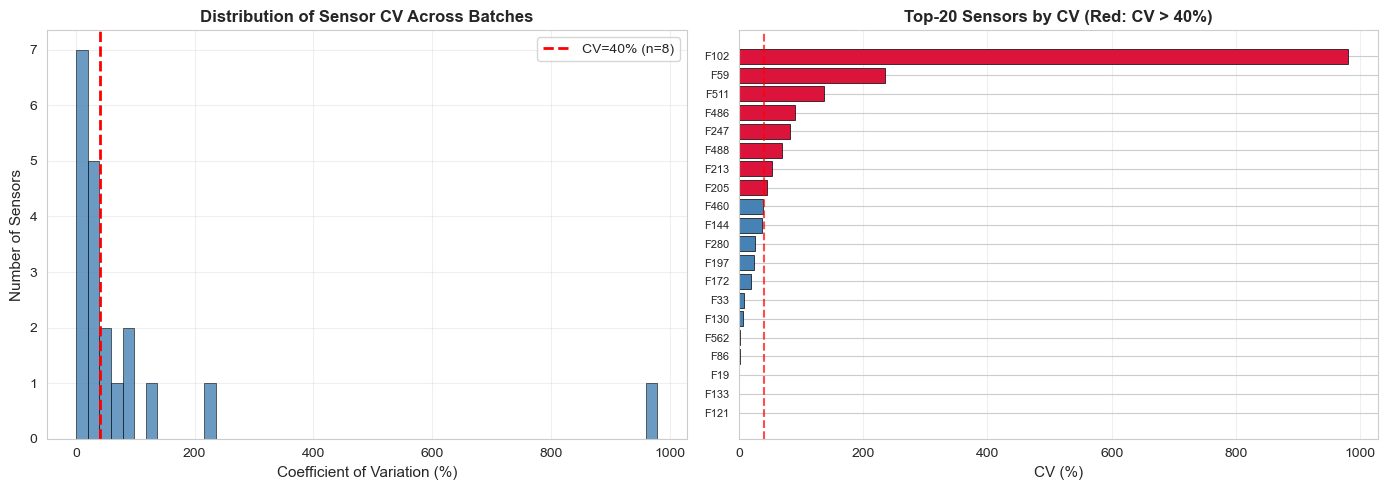

[CV] viz_v8_cv_distribution.png 已保存


In [ ]:
# ================================================
# 可视化 1: CV 分布直方图
# ================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(cv_df["cv_pct"], bins=50, color="steelblue",
         edgecolor="black", linewidth=0.5, alpha=0.8)
ax1.axvline(x=40, color="red", linestyle="--", linewidth=2,
            label=f"CV=40% (n={(cv_df['cv'] > 0.40).sum()})")
ax1.set_xlabel("Coefficient of Variation (%)", fontsize=11)
ax1.set_ylabel("Number of Sensors", fontsize=11)
ax1.set_title("Distribution of Sensor CV Across Batches",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

ax2 = axes[1]
top20_cv = cv_df.head(20)
colors = ["crimson" if cv > 40 else "steelblue" for cv in top20_cv["cv_pct"]]
bars = ax2.barh(range(len(top20_cv)), top20_cv["cv_pct"].values[::-1],
               color=colors[::-1], edgecolor="black", linewidth=0.5)
ax2.axvline(x=40, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
ax2.set_yticks(range(len(top20_cv)))
ax2.set_yticklabels([str(f) for f in top20_cv["feature"].values[::-1]], fontsize=8)
ax2.set_xlabel("CV (%)", fontsize=11)
ax2.set_title("Top-20 Sensors by CV (Red: CV > 40%)",
              fontsize=12, fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("Image/viz_v8_cv_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("[CV] viz_v8_cv_distribution.png 已保存")



## 16. CV 与 SHAP 联合风险图

将批次波动 CV 与 SHAP 重要性联合分析，识别高波动且高重要性的重点工艺传感器。


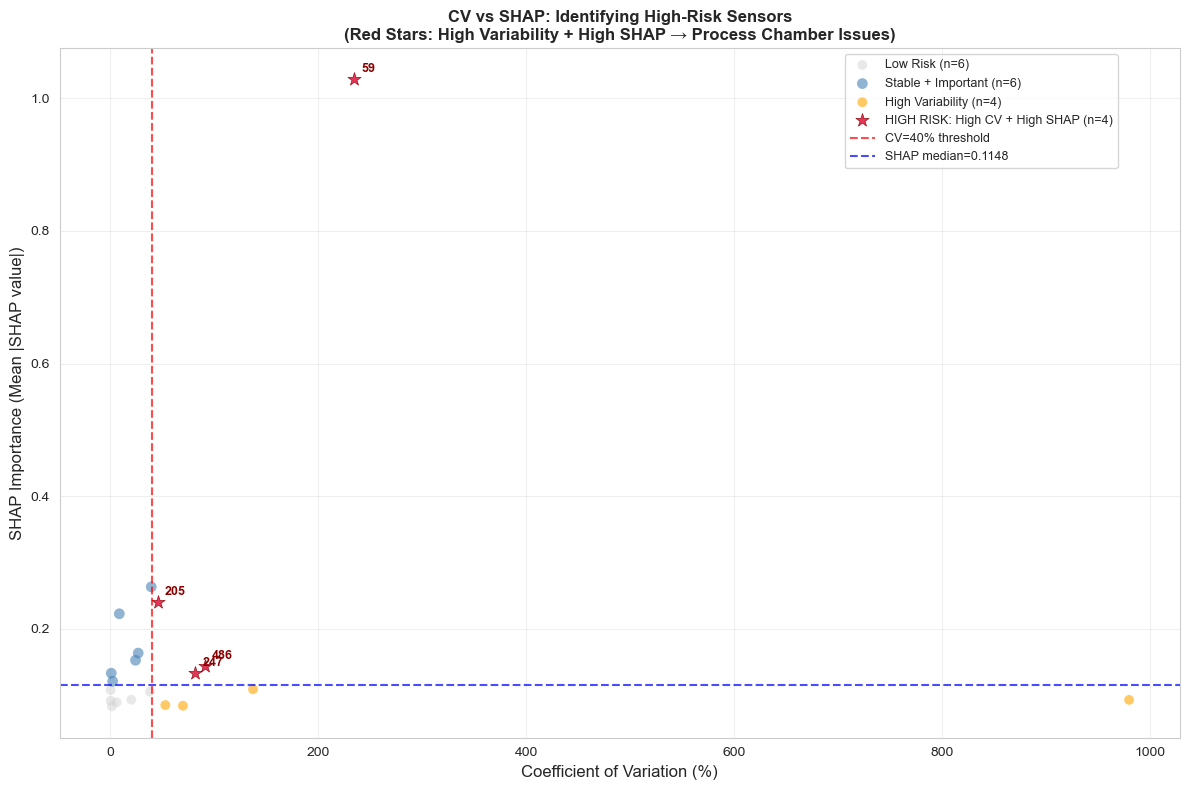

[CV] viz_v8_cv_shap_scatter.png 已保存


In [ ]:
# ================================================
# 可视化 2: CV vs SHAP 散点图（识别高风险传感器）
# ================================================
fig, ax = plt.subplots(figsize=(12, 8))

# 计算阈值
cv_threshold = 0.40  # 40% (可调整)
shap_threshold = np.median(merged["shap"])

# 四个象限分类
q1 = merged[(merged["cv"] <= cv_threshold) & (merged["shap"] >= shap_threshold)]
q2 = merged[(merged["cv"] > cv_threshold) & (merged["shap"] >= shap_threshold)]
q3 = merged[(merged["cv"] <= cv_threshold) & (merged["shap"] < shap_threshold)]
q4 = merged[(merged["cv"] > cv_threshold) & (merged["shap"] < shap_threshold)]

# 绘制四个象限（按风险从低到高）
ax.scatter(q3["cv_pct"], q3["shap"], c="lightgray", s=50, alpha=0.5,
           label=f"Low Risk (n={len(q3)})", edgecolors="none")
ax.scatter(q1["cv_pct"], q1["shap"], c="steelblue", s=60, alpha=0.6,
           label=f"Stable + Important (n={len(q1)})", edgecolors="none")
ax.scatter(q4["cv_pct"], q4["shap"], c="orange", s=50, alpha=0.6,
           label=f"High Variability (n={len(q4)})", edgecolors="none")
ax.scatter(q2["cv_pct"], q2["shap"], c="crimson", s=100, alpha=0.85,
           marker="*", label=f"HIGH RISK: High CV + High SHAP (n={len(q2)})",
           edgecolors="darkred", linewidths=0.5)

# 标注高风险传感器
for _, row in q2.iterrows():
    ax.annotate(f"{row['feature']}",
                 (row["cv_pct"], row["shap"]),
                 fontsize=9, fontweight="bold",
                 xytext=(5, 5), textcoords="offset points",
                 color="darkred")

# 阈值线
ax.axvline(x=cv_threshold * 100, color="red", linestyle="--", linewidth=1.5,
           alpha=0.7, label=f"CV={cv_threshold*100:.0f}% threshold")
ax.axhline(y=shap_threshold, color="blue", linestyle="--", linewidth=1.5,
           alpha=0.7, label=f"SHAP median={shap_threshold:.4f}")

ax.set_xlabel("Coefficient of Variation (%)", fontsize=12)
ax.set_ylabel("SHAP Importance (Mean |SHAP value|)", fontsize=12)
ax.set_title("CV vs SHAP: Identifying High-Risk Sensors\n"
             "(Red Stars: High Variability + High SHAP → Process Chamber Issues)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Image/viz_v8_cv_shap_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[CV] viz_v8_cv_shap_scatter.png 已保存")



## 17. 高 SHAP 传感器批次箱线图

展示 Top SHAP 传感器在训练期批次上的 CV 分布，辅助定位批次波动问题。


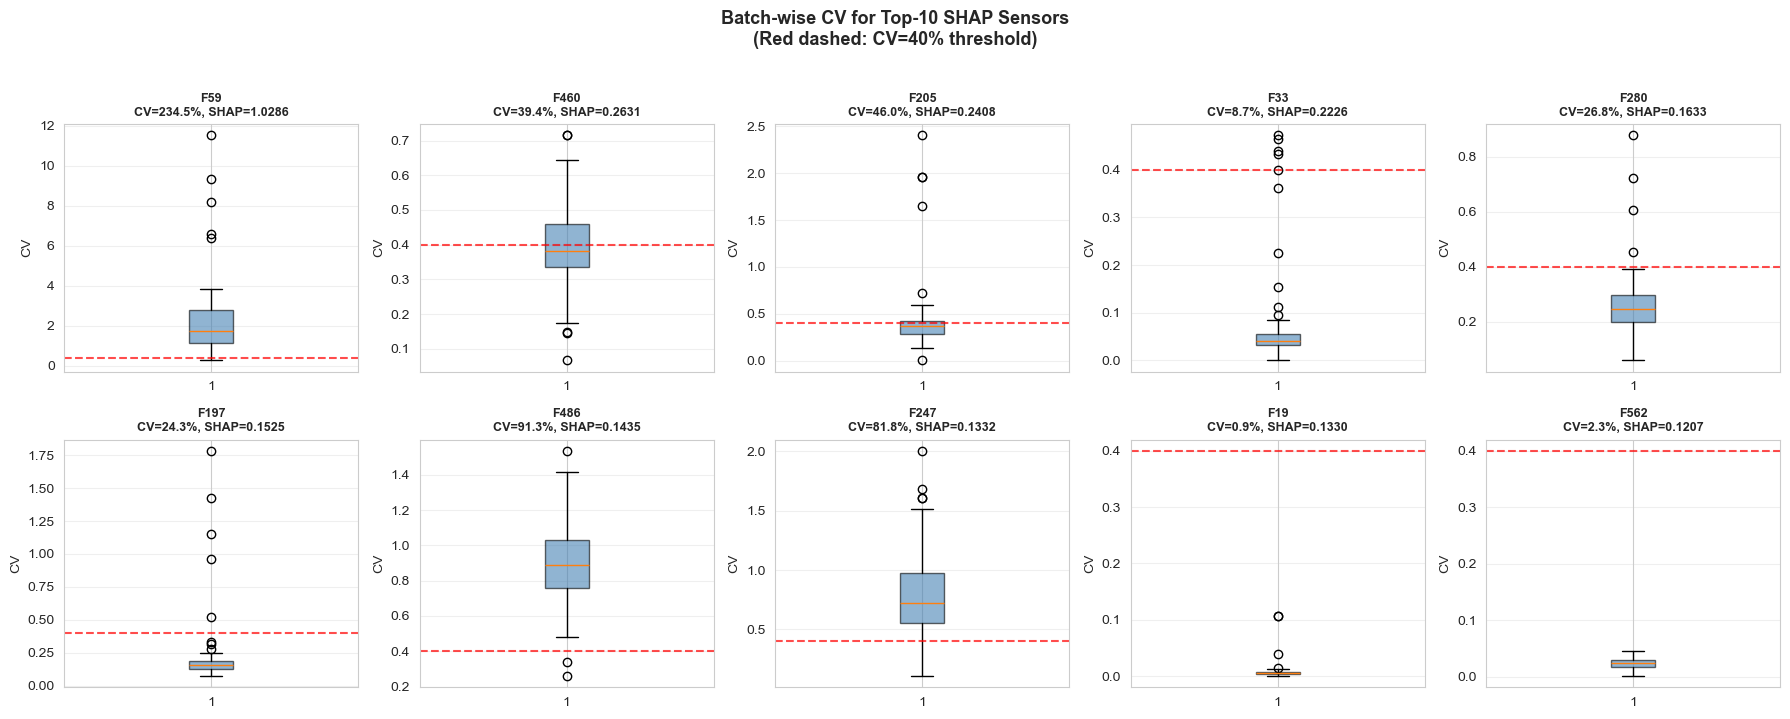

[CV] viz_v8_cv_batch_boxplot.png 已保存


In [ ]:
# ================================================
# 可视化 3: 高 SHAP 传感器的批次 CV 箱线图
# ================================================
top_shap_feats = merged.head(10)["feature_idx"].values
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat_idx in enumerate(top_shap_feats):
    ax = axes[i]
    feat_col = int(feat_idx)
    feat_name = f"F{feat_col}"

    # 计算每个批次的 CV
    batch_cv_vals = {}
    for batch in train_batches:
        batch_mask = batch_cv == batch
        vals = df_cv.loc[batch_mask, feat_col].dropna()
        if len(vals) >= 2 and abs(vals.mean()) > 1e-6:
            batch_cv_vals[batch] = vals.std() / abs(vals.mean())

    cv_vals = list(batch_cv_vals.values())
    feat_cv = cv_df[cv_df["feature_idx"] == feat_col]["cv_pct"].values
    feat_cv_str = f"{feat_cv[0]:.1f}%" if len(feat_cv) > 0 else "N/A"
    feat_shap = merged[merged["feature_idx"] == feat_col]["shap"].values
    feat_shap_str = f"{feat_shap[0]:.4f}" if len(feat_shap) > 0 else "N/A"

    if cv_vals:
        ax.boxplot(cv_vals, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
    else:
        ax.text(0.5, 0.5, "No valid batch CV", ha="center", va="center",
                transform=ax.transAxes, fontsize=8)
    ax.axhline(y=0.40, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    ax.set_title(f"{feat_name}\nCV={feat_cv_str}, SHAP={feat_shap_str}",
                 fontsize=9, fontweight="bold")
    ax.set_ylabel("CV")
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(top_shap_feats):]:
    ax.axis("off")

plt.suptitle("Batch-wise CV for Top-10 SHAP Sensors\n(Red dashed: CV=40% threshold)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("Image/viz_v8_cv_batch_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("[CV] viz_v8_cv_batch_boxplot.png 已保存")



## 18. 关键发现汇总


In [22]:
# ================================================
# 关键发现汇总
# ================================================
print("\n" + "=" * 70)
print("[CV Analysis] 关键发现汇总")
print("=" * 70)

# 高风险传感器: SHAP 高 + CV > 40%
high_risk = merged[(merged["cv"] > 0.40) & (merged["shap"] >= shap_threshold)]
high_risk = high_risk.sort_values("shap", ascending=False)

print(f"\n【高风险传感器】(SHAP >= {shap_threshold:.4f} 且 CV > 40%):")
print(f"  数量: {len(high_risk)} 个")
if len(high_risk) > 0:
    print(f"\n  {'特征':<10} {'CV (%)':<12} {'SHAP':<12} {'风险描述'}")
    print(f"  {'-'*60}")
    for _, row in high_risk.iterrows():
        desc = ""  # 简化描述
        print(f"  {str(row['feature']):<10} {row['cv_pct']:>10.1f}% {row['shap']:>12.4f}  ⬆ 高变异 + 主导失效")

print(f"\n【工艺改进建议】")
if len(high_risk) > 0:
    for _, row in high_risk.iterrows():
        feat = row["feature"]
        cv_val = row["cv_pct"]
        print(f"  - {feat} (CV={cv_val:.1f}%): 建议对该传感器对应的工艺参数进行")
        print(f"    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。")

print(f"\n【象限分析统计】")
print(f"  高 CV + 高 SHAP (重点监控): {((merged['cv'] > 0.40) & (merged['shap'] >= shap_threshold)).sum() if len(merged) > 0 else 0} 个")
print(f"  低 CV + 高 SHAP (稳定关键): {((merged['cv'] <= 0.40) & (merged['shap'] >= shap_threshold)).sum()} 个")
print(f"  高 CV + 低 SHAP (批次波动): {((merged['cv'] > 0.40) & (merged['shap'] < shap_threshold)).sum()} 个")
print(f"  低 CV + 低 SHAP (正常传感器): {((merged['cv'] <= 0.40) & (merged['shap'] < shap_threshold)).sum()} 个")

# 关联分析: 失效样本的 CV 是否更高?
print(f"\n【失效关联分析】")
fail_probs_sorted = np.sort(test_fail_prob)[::-1]
high_prob_mask = test_fail_prob >= np.percentile(test_fail_prob, 75)
low_prob_mask = test_fail_prob <= np.percentile(test_fail_prob, 25)
print(f"  高失效概率样本 (top 25%): {high_prob_mask.sum()} 个")
print(f"  低失效概率样本 (bottom 25%): {low_prob_mask.sum()} 个")




[CV Analysis] 关键发现汇总

【高风险传感器】(SHAP >= 0.1148 且 CV > 40%):
  数量: 4 个

  特征         CV (%)       SHAP         风险描述
  ------------------------------------------------------------
  59              234.5%       1.0286  ⬆ 高变异 + 主导失效
  205              46.0%       0.2408  ⬆ 高变异 + 主导失效
  486              91.3%       0.1435  ⬆ 高变异 + 主导失效
  247              81.8%       0.1332  ⬆ 高变异 + 主导失效

【工艺改进建议】
  - 59 (CV=234.5%): 建议对该传感器对应的工艺参数进行
    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。
  - 205 (CV=46.0%): 建议对该传感器对应的工艺参数进行
    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。
  - 486 (CV=91.3%): 建议对该传感器对应的工艺参数进行
    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。
  - 247 (CV=81.8%): 建议对该传感器对应的工艺参数进行
    实时监控，设置批次间波动告警阈值，并追溯上游设备状态记录。

【象限分析统计】
  高 CV + 高 SHAP (重点监控): 4 个
  低 CV + 高 SHAP (稳定关键): 6 个
  高 CV + 低 SHAP (批次波动): 4 个
  低 CV + 低 SHAP (正常传感器): 6 个

【失效关联分析】
  高失效概率样本 (top 25%): 79 个
  低失效概率样本 (bottom 25%): 79 个
